# 32_04 — Evaluación predictiva · Escenario R (recursión par + tendencia cúbica) · **barrido en $M$**

Paso **3b** del ciclo. Supone que `32_03_convergencia` dio veredicto OK **en
cada punto del barrido**; si las cadenas de un $M$ no convergieron, sus cifras
aquí no significan nada.

## Qué se reporta

| Sección | Qué responde |
|---|---|
| 1 | imports, rutas y constantes |
| 2 | trazas MCMC |
| 3 | predicción funcional a $h=1$ y su intervalo de credibilidad — se PERSISTEN, es lo que consume `32_05` |
| 4 | **Bloque A** (MAE, RMSE, error máximo) sobre la ventana móvil, y qué $M$ gana en cada ventana |
| 5 | **Bloque B** (Winkler, cobertura simultánea, cobertura puntual, MPIW) sobre la ventana móvil |
| 6 | muestra de predicciones: extractos regulares del test, y las peores ventanas según la métrica que se elija, con la curva anterior al lado |
| 7 | probabilidades posteriores de inclusión (PIP) contra la estructura del generador |
| 8 | cuadro resumen: mínimo, máximo y promedio de cada métrica sobre la ventana |
| 9 | monitoreo univariado por componente FPCA: MAE, RMSE y MISE de cada score, por separado |

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.


## 1. Imports, rutas y artefactos

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import (
    PropagadorFuncional,
    ruta_traza, leer_traza, ModeloTraza,   # convencion de trazas (§2)
)

from model_psbp_fd.fit import (
    mise,                                    # piso de truncamiento (§3)
    intervalo_muestral,                      # banda sobre los scores (§3)
    agrupar_momentos,                        # media/sd entre cadenas (§3)
    ventana_movil_scores, ventana_movil_funcional,   # el motor de §4/5/9
    indicador_cobertura,                     # I_t puntual (§8)
    indicador_cobertura_simultanea,          # I_t simultaneo (§8)
    matriz_pip, contraste_con_verdad,        # §7
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_extractos_curvas,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


In [4]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] 
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario_R", 1, 1
M_FPCA_LIST = (1, 2, 3)

SALTAR_M_SIN_TRAZAS = True

PESOS_TAU = None

METRICA_PEORES = "rmse_f"   # cualquiera de METRICAS_MONITOR (nivel funcional)
N_PEORES = 5

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
assert len(set(M_FPCA_LIST)) == len(M_FPCA_LIST), "M_FPCA_LIST tiene repetidos."

EXPERIMENT_BASE = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"


def experiment_id(M: int) -> str:
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M      = {M: rutas(M) for M in M_FPCA_LIST}
PATH_BARRIDO = PROJECT_ROOT / "reports" / "simulaciones" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}")
print(f"salidas cruzadas de M : {PATH_BARRIDO}   "
      "(ventana movil por M, prefijo 88_*)")


METRICAS_A = [
    (u"1. MAE   (L^1)",             "mae_f"),
    (u"2. RMSE  (L^2)",             "rmse_f"),
    # Promedio, sobre la ventana, del maximo REAL de cada curva (no un
    # cuantil que lo aproxima): por curva, ||e_t||_inf = max_tau |e_t(tau)|;
    # por ventana, el promedio de esas w cifras. Con w=20, "20 curvas, cada
    # una con su error maximo, promediados" es literalmente esta columna.
    (u"3. Error maximo (L^inf, prom. por curva)", "linf_medio"),
]
METRICAS_B = [
    (u"4. Winkler",                 "winkler"),
    # PICP puntual: fraccion de PARES (t, tau) cubiertos. Es la que decompone
    # el Winkler -este integra sobre tau- y por eso no se reemplaza.
    (u"6a. PICP puntual",           "picp"),
    # PICP simultaneo: fraccion de CURVAS enteras contenidas en su banda. Con
    # w=20 y 18 curvas totalmente dentro, esta columna vale 18/20 = 0.90.
    # Es SIEMPRE <= PICP puntual: basta un tau fuera para que la curva entera
    # cuente como no cubierta.
    (u"6b. PICP simultaneo (curva completa)", "picp_simultaneo"),
    (u"7. MPIW",                    "mpiw"),
]
METRICAS_MONITOR = METRICAS_A + METRICAS_B

print("")
print("metricas monitoreadas (nivel funcional, en orden):")
for _et, _cw in METRICAS_MONITOR:
    print("   %-40s  columna=%s" % (_et, _cw))
print("   5. I_t puntual y simultaneo (series por origen)  ->  "
      "67_indicador_cobertura.csv")

# Columnas de cada bloque, para que §4 y §5 dibujen SOLO lo suyo en una vista
# cada uno -sin mezclar Bloque A con Bloque B, que es lo que pide la
# especificacion-.
METRICAS_A_COLS = [c for _, c in METRICAS_A]
METRICAS_B_COLS = [c for _, c in METRICAS_B]



barrido en M : [1, 2, 3]
  M=1  ->  escenario_R_1_r01_m01
  M=2  ->  escenario_R_1_r01_m02
  M=3  ->  escenario_R_1_r01_m03
salidas cruzadas de M : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_barrido_M   (ventana movil por M, prefijo 88_*)

metricas monitoreadas (nivel funcional, en orden):
   1. MAE   (L^1)                            columna=mae_f
   2. RMSE  (L^2)                            columna=rmse_f
   3. Error maximo (L^inf, prom. por curva)  columna=linf_medio
   4. Winkler                                columna=winkler
   6a. PICP puntual                          columna=picp
   6b. PICP simultaneo (curva completa)      columna=picp_simultaneo
   7. MPIW                                   columna=mpiw
   5. I_t puntual y simultaneo (series por origen)  ->  67_indicador_cobertura.csv


In [5]:
# Estado por punto del barrido. Nada de lo que sigue usa variables globales del
# experimento: todo se lee de EST[M].
EST = {}
saltados = []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 32_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    dfs_test,  _        = cargar_datasets_ar(P, bloque="test")
    hp_json     = cargar_hiperparametros(P)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes.")
    assert manifest["scores_scale"] == "standardized_zscore_ddof0"

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "dfs_test": dfs_test, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": manifest["cov_names"],
        "n_lags": int(manifest["n_lags"]),
        "T": int(manifest["T"]), "T0": int(manifest["T0"]),
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "burn": int(hp_json["mcmc_config"]["burn"]),
        # Parámetros de evaluación: se LEEN del artefacto, no se redeclaran.
        "nivel": float(eval_config.get("nivel_credibilidad", 0.95)),
        "modo_residuo": eval_config.get("modo_residuo", "ninguno"),
        "objetivo": eval_config.get("objetivo_evaluacion", "curva_verdadera"),
        "ventanas_w": list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40])),
    }
    EST[M]["n_post"] = EST[M]["mcmc_cfg"]["nsim"] - EST[M]["burn"]

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 32_01 primero."

for M, e in EST.items():
    print(f"M={M}  T={e['T']} T0={e['T0']} n_lags={e['n_lags']} "
          f"componentes={e['n_components']}  nivel={e['nivel']}  "
          f"modo_residuo={e['modo_residuo']!r}  objetivo={e['objetivo']!r}")
for M, motivo in saltados:
    print(f"  ! M={M} saltado: {motivo}")

# La comparación entre M sólo tiene sentido si el diseño de observación, la
# partición y el objetivo de evaluación son los mismos en todos los puntos: si
# no, las diferencias mezclarían el efecto de M con el de otra cosa.
_comun = {M: (e["T"], e["T0"], e["n_lags"], e["nivel"], e["modo_residuo"],
              e["objetivo"], tuple(e["ventanas_w"]), e["n_iter"],
              e["mcmc_cfg"]["nsim"], e["mcmc_cfg"]["N"], e["burn"])
          for M, e in EST.items()}
if len(set(_comun.values())) > 1:
    print("\n! Los puntos del barrido NO comparten diseño/evaluación:")
    for M, v in _comun.items():
        print(f"    M={M}: {v}")
    raise AssertionError(
        "El barrido en M exige T, T0, n_lags, nivel, modo_residuo, objetivo, "
        "ventanas y configuración MCMC idénticos. Regenera los puntos que "
        "difieren antes de comparar.")
print("\nOK todos los puntos comparten diseño de observación, partición, "
      "objetivo de evaluación y configuración MCMC.")

# Alias de las cantidades comunes, para no repetir EST[M][...] en cada celda.
T          = EST[next(iter(EST))]["T"]
T0         = EST[next(iter(EST))]["T0"]
N_LAGS     = EST[next(iter(EST))]["n_lags"]
NIVEL      = EST[next(iter(EST))]["nivel"]
MODO_RESIDUO = EST[next(iter(EST))]["modo_residuo"]
OBJETIVO   = EST[next(iter(EST))]["objetivo"]
VENTANAS_W = EST[next(iter(EST))]["ventanas_w"]
W_REF      = VENTANAS_W[len(VENTANAS_W) // 2]
print(f"ventanas w = {VENTANAS_W}   ·   referencia w={W_REF}")
print(f"IC de la curva: NIVEL = 1 - alpha = {NIVEL:.2f}   ->   alpha = {1 - NIVEL:.2f}   (cuantiles F^-1(alpha/2), F^-1(1 - alpha/2))")


M=1  T=800 T0=560 n_lags=1 componentes=1  nivel=0.95  modo_residuo='ninguno'  objetivo='curva_verdadera'
M=2  T=800 T0=560 n_lags=1 componentes=2  nivel=0.95  modo_residuo='ninguno'  objetivo='curva_verdadera'
M=3  T=800 T0=560 n_lags=1 componentes=3  nivel=0.95  modo_residuo='ninguno'  objetivo='curva_verdadera'

OK todos los puntos comparten diseño de observación, partición, objetivo de evaluación y configuración MCMC.
ventanas w = [10, 20, 40]   ·   referencia w=20
IC de la curva: NIVEL = 1 - alpha = 0.95   ->   alpha = 0.05   (cuantiles F^-1(alpha/2), F^-1(1 - alpha/2))


In [6]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)          # (T, G) con ruido
    X_true        = cargar_curvas_true(P)     # (T, G) verdadera - el objetivo

    assert e["component_idx"] == list(range(fpca.M)), (
        "La propagación funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "Psi_grid": fpca.Psi_grid, "mu_grid": fpca.mu_grid,
              "SCORES": fpca.SCORES,
              "var_explicada": float(fpca.meta["var_explained"])})

    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  var. explicada="
          f"{e['var_explicada']:.4%}  ·  curvas {X_true.shape}  "
          f"grilla {grilla.shape}")

# Las curvas y la grilla son las MISMAS en todos los puntos: el generador y la
# semilla no dependen de M, sólo cambia cuántas componentes se retienen. Si no
# coincidieran, el MISE de dos M no sería sobre los mismos datos.
_M0 = next(iter(EST))
for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas verdaderas difieren de las de M={_M0}: los puntos "
        "del barrido no salen de la misma simulación.")
    assert np.allclose(EST[M]["grilla"], EST[_M0]["grilla"])
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
X_obs  = EST[_M0]["X_obs"]
print(f"\nOK las {len(EST)} representaciones vienen de la MISMA simulación: "
      "las diferencias entre M son de representación, no de datos.")
print(f"sd(observada - verdadera) = {(X_obs - X_true).std():.4f}   "
      "<- el ruido que el modelo NO debe predecir")

M=1  FPCA M=1 K=6  var. explicada=85.8696%  ·  curvas (800, 100)  grilla (100,)
M=2  FPCA M=2 K=6  var. explicada=97.7019%  ·  curvas (800, 100)  grilla (100,)
M=3  FPCA M=3 K=6  var. explicada=99.7047%  ·  curvas (800, 100)  grilla (100,)

OK las 3 representaciones vienen de la MISMA simulación: las diferencias entre M son de representación, no de datos.
sd(observada - verdadera) = 0.2497   <- el ruido que el modelo NO debe predecir


In [7]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)          # (T, G) con ruido
    X_true        = cargar_curvas_true(P)     # (T, G) verdadera - el objetivo

    assert e["component_idx"] == list(range(fpca.M)), (
        "La propagación funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "Psi_grid": fpca.Psi_grid, "mu_grid": fpca.mu_grid,
              "SCORES": fpca.SCORES,
              "var_explicada": float(fpca.meta["var_explained"])})

    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  var. explicada="
          f"{e['var_explicada']:.4%}  ·  curvas {X_true.shape}  "
          f"grilla {grilla.shape}")

# Las curvas y la grilla son las MISMAS en todos los puntos: el generador y la
# semilla no dependen de M, sólo cambia cuántas componentes se retienen. Si no
# coincidieran, el MISE de dos M no sería sobre los mismos datos.
_M0 = next(iter(EST))
for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas verdaderas difieren de las de M={_M0}: los puntos "
        "del barrido no salen de la misma simulación.")
    assert np.allclose(EST[M]["grilla"], EST[_M0]["grilla"])
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
X_obs  = EST[_M0]["X_obs"]
print(f"\nOK las {len(EST)} representaciones vienen de la MISMA simulación: "
      "las diferencias entre M son de representación, no de datos.")
print(f"sd(observada - verdadera) = {(X_obs - X_true).std():.4f}   "
      "<- el ruido que el modelo NO debe predecir")

M=1  FPCA M=1 K=6  var. explicada=85.8696%  ·  curvas (800, 100)  grilla (100,)
M=2  FPCA M=2 K=6  var. explicada=97.7019%  ·  curvas (800, 100)  grilla (100,)
M=3  FPCA M=3 K=6  var. explicada=99.7047%  ·  curvas (800, 100)  grilla (100,)

OK las 3 representaciones vienen de la MISMA simulación: las diferencias entre M son de representación, no de datos.
sd(observada - verdadera) = 0.2497   <- el ruido que el modelo NO debe predecir


## 2. Trazas MCMC

Una lectura por punto del barrido. El `feature_names` del `.mat` se verifica
contra las columnas del dataset: con $M$ distintos el número de covariables
cambia, y un `.mat` del punto equivocado se detectaría aquí y no más adelante
como un resultado raro.

In [8]:
sin_trazas = []

for M in list(EST):
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not ruta_traza(P, ci[k] + 1, c + 1).exists()]
    if faltan:
        msg = f"faltan {len(faltan)} trazas: {faltan[:3]}{'...' if len(faltan) > 3 else ''}"
        if not SALTAR_M_SIN_TRAZAS:
            raise AssertionError(f"[M={M}] {msg}\nEjecuta psbp_fd_iteracion.m.")
        sin_trazas.append((M, msg))
        del EST[M]
        continue

    models_chains = {k: {} for k in range(n_comp)}
    for k in range(n_comp):
        esperado = list(e["dfs_train"][k].columns[1:])
        for c in range(n_iter):
            traces, burn, feat = leer_traza(ruta_traza(P, ci[k] + 1, c + 1))
            assert feat == esperado, (
                f"[M={M} k={k} c={c+1}] feature_names != columnas del dataset:\n"
                f"  mat  = {feat}\n  train= {esperado}")
            models_chains[k][c] = ModeloTraza(traces, burn, feat)
    e["models_chains"] = models_chains
    print(f"OK M={M}: {n_comp} x {n_iter} cadenas · {e['n_post']} draws "
          f"posteriores c/u  ·  p={models_chains[0][0].n_features_}")

assert EST, ("Ningún punto del barrido tiene trazas. Ejecuta "
             "psbp_fd_iteracion.m con M_FPCA_LIST antes de este notebook.")
for M, motivo in sin_trazas:
    print(f"! M={M} saltado: {motivo}")

M_OK = tuple(sorted(EST))
print(f"\npuntos evaluables: M = {list(M_OK)}")

OK M=1: 1 x 2 cadenas · 2000 draws posteriores c/u  ·  p=1
OK M=2: 2 x 2 cadenas · 2000 draws posteriores c/u  ·  p=2
OK M=3: 3 x 2 cadenas · 2000 draws posteriores c/u  ·  p=3

puntos evaluables: M = [1, 2, 3]


## 3. Predicción a $h=1$ sobre la serie completa


In [9]:
# Número de extracciones de la predictiva por draw posterior. El total es
#     S = (nsim - burn) × S_POR_ITER × n_cadenas
# y d=1 ya da varios miles: subirlo sólo reduce el error Monte Carlo de estimar
# los cuantiles, no cambia la predictiva.
S_POR_ITER = 10
S_FUNC     = 2000        # muestras funcionales tras adelgazar
SEED_PRED  = 20260823
CADA       = 30        # [CONFIG] un extracto de curva cada CADA períodos

# Serie de orígenes: es la MISMA en todos los M (T, T0 y n_lags son comunes).
t_orig   = np.arange(N_LAGS + 1, T + 1)      # tiempo del experimento, base-1
n_orig   = len(t_orig)
T0_orig  = T0 - N_LAGS                       # corte dentro de la serie de orígenes
es_train = t_orig <= T0
print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")

_mem = sum(EST[M]["n_post"] * S_POR_ITER * EST[M]["n_iter"] * n_orig
           * EST[M]["n_components"] * 4 for M in M_OK) / 1e9
print(f"SC_draws de TODO el barrido reservará {_mem * 1e3:.0f} MB en float32")
assert _mem < 2.0, (
    f"SC_draws pediría {_mem:.1f} GB sumando los M. Baja S_POR_ITER o acorta "
    "M_FPCA_LIST antes de continuar.")
print(f"X_draws se libera dentro del bucle: pico ≈ "
      f"{S_FUNC * n_orig * len(grilla) * 8 / 1e6:.0f} MB (un solo M a la vez)")

orígenes evaluados: 799  (train 559 · test 240)
SC_draws de TODO el barrido reservará 767 MB en float32
X_draws se libera dentro del bucle: pico ≈ 1278 MB (un solo M a la vez)


In [10]:
for M in M_OK:
    e = EST[M]
    n_comp, n_iter, n_post = e["n_components"], e["n_iter"], e["n_post"]
    ci = e["component_idx"]

    dfs_full = {k: pd.concat([e["dfs_train"][k], e["dfs_test"][k]],
                             ignore_index=True) for k in range(n_comp)}
    assert len(dfs_full[0]) == n_orig, f"[M={M}] {len(dfs_full[0])} != {n_orig}"

    # -- momentos y extracciones por score, agrupando cadenas ----------------
    #    momentos : ley de varianza total entre cadenas (fit.agrupar_momentos)
    #    muestras : concatenación, que es la mezcla de igual peso
    Y_obs = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy()
                             for k in range(n_comp)])
    Y_hat = np.empty_like(Y_obs)
    Y_sd  = np.empty_like(Y_obs)

    S_POR_CADENA = n_post * S_POR_ITER
    S_total      = S_POR_CADENA * n_iter
    SC_draws     = np.empty((S_total, n_orig, n_comp), dtype=np.float32)

    for k in range(n_comp):
        medias, sds = [], []
        for j, c in enumerate(sorted(e["models_chains"][k])):
            mom = e["models_chains"][k][c].momentos(dfs_full[k])
            medias.append(mom["media"])
            sds.append(mom["sd"])          # PREDICTIVA (v3), no la del centro
            muestras_c = e["models_chains"][k][c].muestrear(
                dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c + 97 * M)
            assert muestras_c.shape == (S_POR_CADENA, n_orig), (
                f"[M={M} k={k} c={c}] muestrear devolvió {muestras_c.shape}; se "
                f"esperaba ({S_POR_CADENA}, {n_orig}).")
            SC_draws[j * S_POR_CADENA:(j + 1) * S_POR_CADENA, :, k] = muestras_c
            del muestras_c
        Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                                   np.column_stack(sds))

    li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)     # (n_orig, M)

    # -- propagación a la curva ---------------------------------------------
    paso_thin = max(1, S_total // S_FUNC)
    propagador = PropagadorFuncional(e["Psi_grid"], e["mu_grid"],
                                     estandarizador=e["std"],
                                     modo_residuo=MODO_RESIDUO)
    X_draws = propagador.curvas_desde_scores(SC_draws[::paso_thin], seed=SEED_PRED)
    X_pred  = X_draws.mean(axis=0)                              # (n, G)
    li_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0)
    ls_f = np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

    X_true_ev = X_true[N_LAGS:]      # (n_orig, G) VERDADERA - contra esto se evalúa
    X_obs_ev  = X_obs[N_LAGS:]       # (n_orig, G) observada, sólo para las figuras
    X_proj    = e["fpca"].reconstruct(e["SCORES"])[N_LAGS:]     # piso de la representación

    S_funcional = int(X_draws.shape[0])
    del X_draws

    e.update({"dfs_full": dfs_full, "Y_obs": Y_obs, "Y_hat": Y_hat, "Y_sd": Y_sd,
              "SC_draws": SC_draws, "li_s": li_s, "ls_s": ls_s,
              "X_pred": X_pred, "li_f": li_f, "ls_f": ls_f, "X_proj": X_proj,
              "S_total": int(S_total),
              "S_funcional": S_funcional, "paso_thin": paso_thin})

    print(f"M={M}: S={S_total} extracciones por score · funcionales "
          f"{S_funcional} (1 de cada {paso_thin}) · SC_draws "
          f"{SC_draws.nbytes / 1e6:.0f} MB")
    print(f"       MISE del TRUNCAMIENTO (test) = "
          f"{mise(X_true_ev[~es_train], X_proj[~es_train], grilla):.6f}"
          "   <- ningún modelo sobre esta representación baja de ahí")

X_true_ev = X_true[N_LAGS:]
X_obs_ev  = X_obs[N_LAGS:]

M=1: S=40000 extracciones por score · funcionales 2000 (1 de cada 20) · SC_draws 128 MB
       MISE del TRUNCAMIENTO (test) = 0.408081   <- ningún modelo sobre esta representación baja de ahí
M=2: S=40000 extracciones por score · funcionales 2000 (1 de cada 20) · SC_draws 256 MB
       MISE del TRUNCAMIENTO (test) = 0.173988   <- ningún modelo sobre esta representación baja de ahí
M=3: S=40000 extracciones por score · funcionales 2000 (1 de cada 20) · SC_draws 384 MB
       MISE del TRUNCAMIENTO (test) = 0.007978   <- ningún modelo sobre esta representación baja de ahí


### 3.1 Persistencia

La banda y la predicción puntual se guardan en `predict/` -no en `reports/`,
es un objeto de datos y no una salida de lectura- porque `32_05` las necesita
para calcular el Winkler del PSBPM-FD sobre su propia ventana móvil sin volver
a muestrear la predictiva completa.

In [11]:

for M in M_OK:
    e = EST[M]
    destino = e["paths"]["predict"] / "banda_funcional_psbp.npz"
    np.savez_compressed(
        destino,
        li=e["li_f"].astype(np.float32), ls=e["ls_f"].astype(np.float32),
        X_pred=e["X_pred"].astype(np.float32),
        t_orig=t_orig, nivel=np.array([NIVEL]),
        n_lags=np.array([N_LAGS]), T0=np.array([T0]),
        modo_residuo=np.array([MODO_RESIDUO]),
        objetivo=np.array([OBJETIVO]))
    print(f"[M={M}] banda funcional -> {destino.name}  "
          f"({destino.stat().st_size / 1e6:.1f} MB, {e['li_f'].shape})")

print("\nEs la banda por CUANTILES de la predictiva muestral: no supone forma")
print("alguna, y es la que el 32_05 contrasta contra la banda gaussiana del")
print("modelo AR.")


[M=1] banda funcional -> banda_funcional_psbp.npz  (0.9 MB, (799, 100))
[M=2] banda funcional -> banda_funcional_psbp.npz  (0.8 MB, (799, 100))
[M=3] banda funcional -> banda_funcional_psbp.npz  (0.8 MB, (799, 100))

Es la banda por CUANTILES de la predictiva muestral: no supone forma
alguna, y es la que el 32_05 contrasta contra la banda gaussiana del
modelo AR.


## 4. Bloque A: error puntual sobre la ventana móvil

Las tres normas del MISMO error $e_t(\tau) = X_t(\tau) - \hat X_t(\tau)$:

| | qué estima | qué añade |
|---|---|---|
| **MAE** ($L^1$) | mediana condicional | robusta: un origen catastrófico no la mueve |
| **RMSE** ($L^2$) | media condicional | la que usa el PSBPM-FD y el resto del capítulo |
| **Error máximo** ($L^\infty$, promedio por curva) | peor caso | por curva, $\max_\tau \lvert e_t(\tau)\rvert$; sobre la ventana, el promedio de esos $w$ máximos |

Todo se calcula UNA vez por M en `tablas_fun` -la misma tabla que consume el
Bloque B de §5- y se dibuja aquí SOLO el Bloque A.

In [12]:
for M in M_OK:
    e = EST[M]
    tablas_fun = {
        w: ventana_movil_funcional(X_true_ev, e["X_pred"], grilla, T0_orig, w=w,
                                   li=e["li_f"], ls=e["ls_f"], t_offset=N_LAGS,
                                   pesos_tau=PESOS_TAU,
                                   nivel=NIVEL, bloque_A=True,
                                   verbose=(w == W_REF))
        for w in VENTANAS_W
    }
    e["tablas_fun"] = tablas_fun
    tablas_fun[W_REF].to_csv(
        e["paths"]["out_report"] / f"57_ventana_funcional_w{W_REF}.csv", index=False)

[ventana_movil_funcional[w=20]] inicio (780 pasos)
  1/780 ( 0.1%) t=0.0s eta=2.3s  t=11 [train] mise=1.628
  39/780 ( 5.0%) t=0.0s eta=0.2s  t=49 [train] mise=1.783
  78/780 (10.0%) t=0.0s eta=0.2s  t=88 [train] mise=1.881
  117/780 (15.0%) t=0.0s eta=0.1s  t=127 [train] mise=1.976
  156/780 (20.0%) t=0.0s eta=0.1s  t=166 [train] mise=1.602
  195/780 (25.0%) t=0.0s eta=0.1s  t=205 [train] mise=2.421
  234/780 (30.0%) t=0.0s eta=0.1s  t=244 [train] mise=1.247
  273/780 (35.0%) t=0.0s eta=0.1s  t=283 [train] mise=1.933
  312/780 (40.0%) t=0.1s eta=0.1s  t=322 [train] mise=1.301
  351/780 (45.0%) t=0.1s eta=0.1s  t=361 [train] mise=1.383
  390/780 (50.0%) t=0.1s eta=0.1s  t=400 [train] mise=2.424
  429/780 (55.0%) t=0.1s eta=0.1s  t=439 [train] mise=2.904
  468/780 (60.0%) t=0.1s eta=0.1s  t=478 [train] mise=1.637
  507/780 (65.0%) t=0.1s eta=0.0s  t=517 [train] mise=2.571
  546/780 (70.0%) t=0.1s eta=0.0s  t=556 [train] mise=2.883
  585/780 (75.0%) t=0.1s eta=0.0s  t=595 [test] mise=3.9

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.1s eta=0.1s  mae_f: w=10 train=1.127  w=10 test=2.093  w=20 train=1.104  w=20 test=2.094  w=40 train=1.106  w=40 test=2.061
  2/3 (66.7%) t=0.1s eta=0.0s  rmse_f: w=10 train=1.399  w=10 test=2.438  w=20 train=1.376  w=20 test=2.491  w=40 train=1.399  w=40 test=2.487
  3/3 (100.0%) t=0.1s eta=0.0s  linf_medio: w=10 train=1.716  w=10 test=3.067  w=20 train=1.696  w=20 test=3.048  w=40 train=1.698  w=40 test=3.016
[plot_ventana_movil] listo: 3 pasos en 0.7s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m01\60_ventana_bloqueA.png


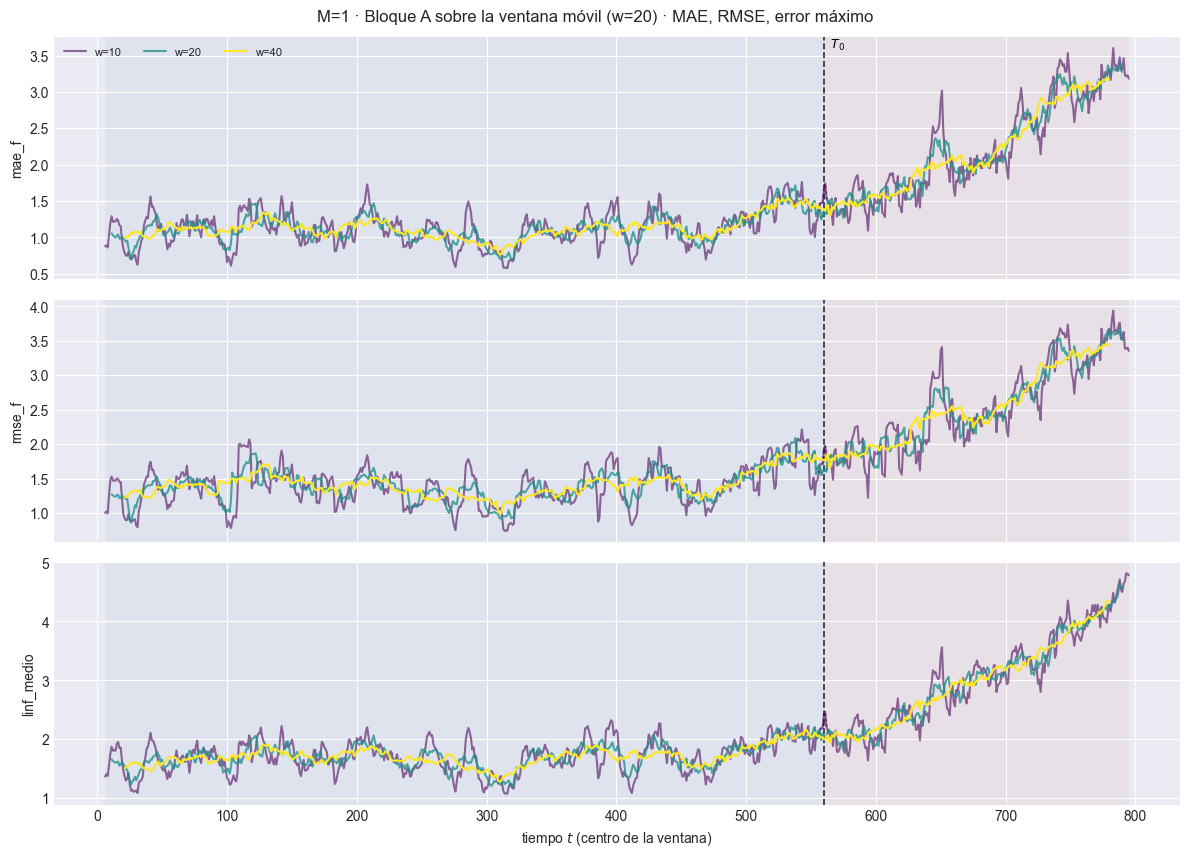

[M=1] cadena L^1 <= L^2 <= L^inf verificada en las 780 ventanas de w=20
[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.1s  mae_f: w=10 train=1.139  w=10 test=2.137  w=20 train=1.116  w=20 test=2.131  w=40 train=1.117  w=40 test=2.106
  2/3 (66.7%) t=0.0s eta=0.0s  rmse_f: w=10 train=1.412  w=10 test=2.46  w=20 train=1.394  w=20 test=2.525  w=40 train=1.413  w=40 test=2.517
  3/3 (100.0%) t=0.1s eta=0.0s  linf_medio: w=10 train=1.733  w=10 test=3.106  w=20 train=1.705  w=20 test=3.08  w=40 train=1.713  w=40 test=3.05
[plot_ventana_movil] listo: 3 pasos en 0.4s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m02\60_ventana_bloqueA.png


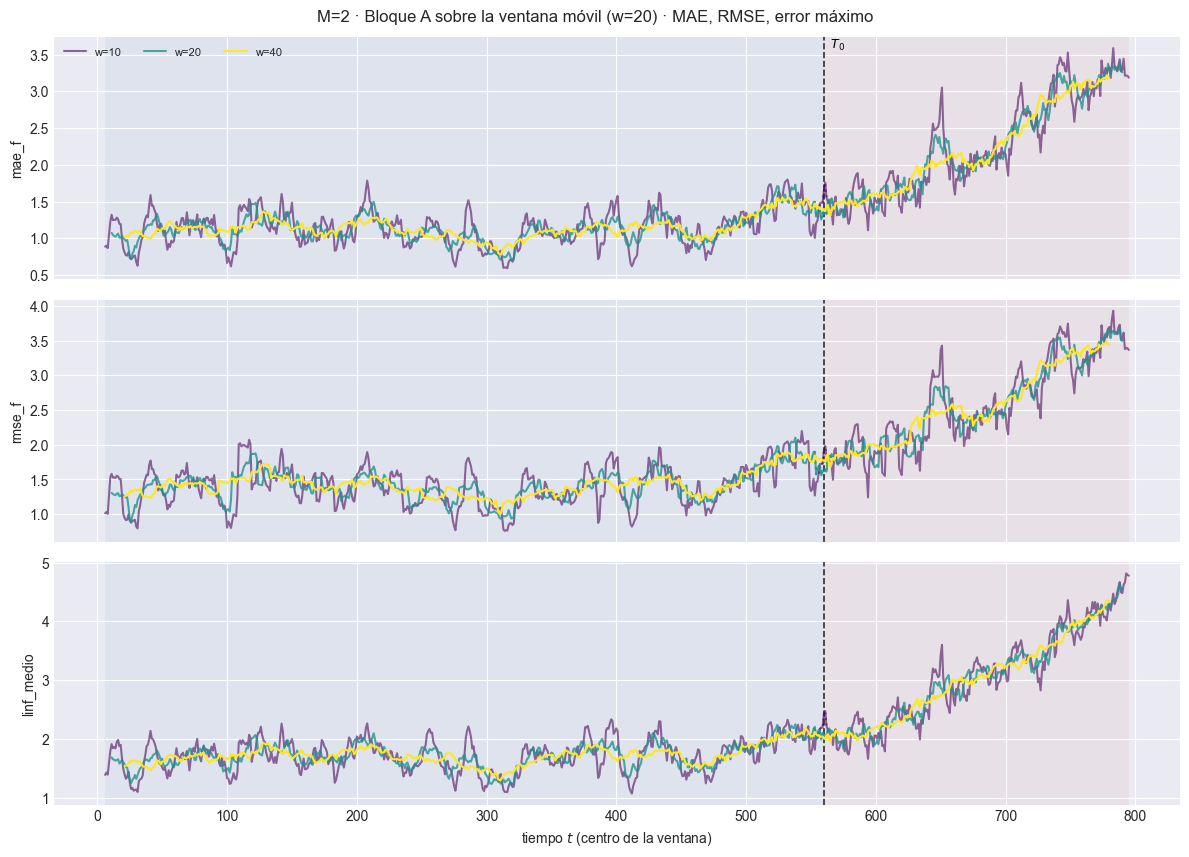

[M=2] cadena L^1 <= L^2 <= L^inf verificada en las 780 ventanas de w=20
[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  mae_f: w=10 train=1.136  w=10 test=2.13  w=20 train=1.111  w=20 test=2.118  w=40 train=1.116  w=40 test=2.087
  2/3 (66.7%) t=0.0s eta=0.0s  rmse_f: w=10 train=1.408  w=10 test=2.455  w=20 train=1.387  w=20 test=2.511  w=40 train=1.404  w=40 test=2.494
  3/3 (100.0%) t=0.0s eta=0.0s  linf_medio: w=10 train=1.726  w=10 test=3.082  w=20 train=1.707  w=20 test=3.06  w=40 train=1.707  w=40 test=3.034
[plot_ventana_movil] listo: 3 pasos en 0.4s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m03\60_ventana_bloqueA.png


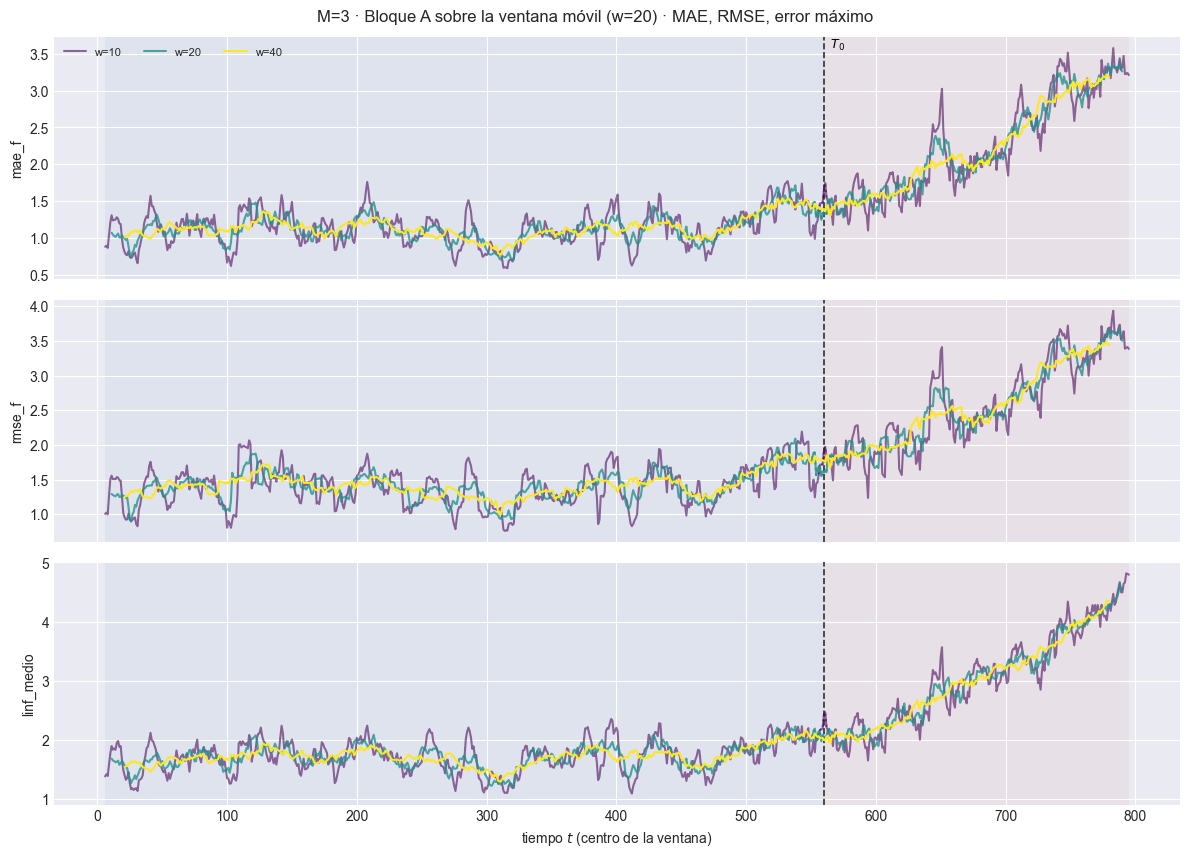

[M=3] cadena L^1 <= L^2 <= L^inf verificada en las 780 ventanas de w=20


In [13]:
# Bloque A, una sola vista: MAE, RMSE, Error máximo, ninguno "primario".
for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]
    faltan = [c for c in METRICAS_A_COLS if c not in tfun.columns]
    assert not faltan, f"[M={M}] faltan columnas del Bloque A: {faltan}"

    plot_ventana_movil(
        tfun, T0, METRICAS_A_COLS, tablas_por_w=e["tablas_fun"],
        title=f"M={M} · Bloque A sobre la ventana móvil (w={W_REF}) · "
              "MAE, RMSE, error máximo",
        save_path=str(e["paths"]["out_report"] / "60_ventana_bloqueA.png"),
        verbose=True)
    plt.show()

    # La cadena L^1 <= L^2 <= L^inf tiene que verse tambien ventana a ventana.
    assert (tfun["mae_f"] <= tfun["rmse_f"] + 1e-9).all(), (
        f"[M={M}] mae_f > rmse_f en alguna ventana: revisar la cuadratura.")
    assert (tfun["rmse_f"] <= tfun["linf_medio"] + 1e-9).all()
    print(f"[M={M}] cadena L^1 <= L^2 <= L^inf verificada en las "
          f"{len(tfun)} ventanas de w={W_REF}")


### 4.1 ¿Qué $M$ gana en cada ventana?

Alineando las ventanas de todos los $M$ por su $t$ central -el diseño es común
entre puntos del barrido, así que las ventanas coinciden posición a posición-,
para cada ventana y cada métrica se marca cuál $M$ dio el valor MÁS BAJO. El
panel de abajo es el porcentaje de ventanas ganadas por cada $M$, separado por
bloque train/test. Se excluyen las ventanas que cruzan $T_0$.

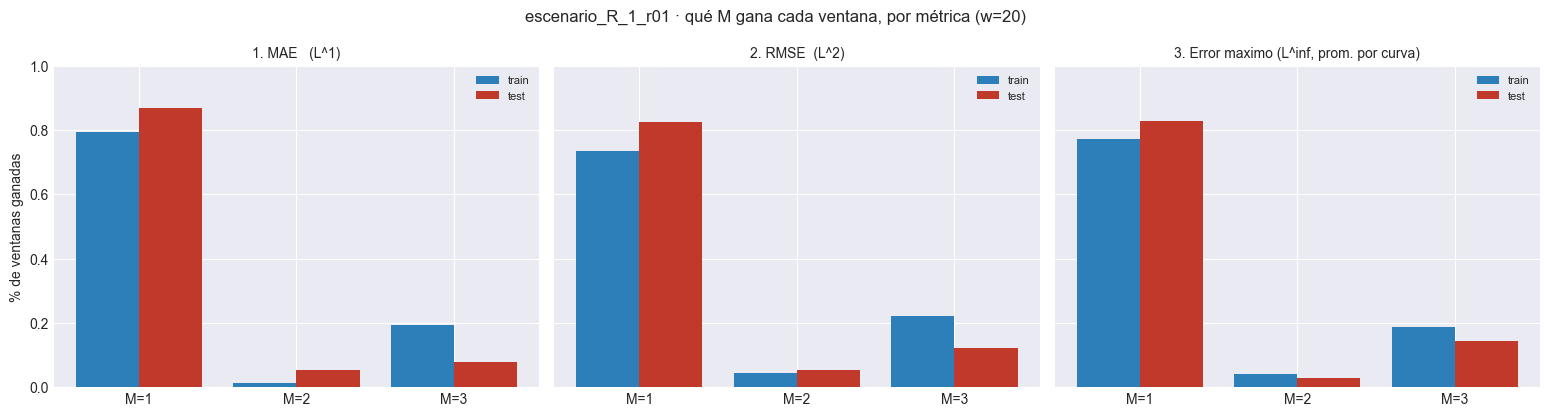

In [14]:

tablas_M = {M: EST[M]["tablas_fun"][W_REF] for M in M_OK}
_ref = tablas_M[M_OK[0]]
for M in M_OK[1:]:
    assert list(tablas_M[M]["t_centro"]) == list(_ref["t_centro"]), (
        f"[M={M}] las ventanas no estan alineadas con M={M_OK[0]}: revisar "
        "que T, T0, n_lags y VENTANAS_W sean comunes (ya se verifico en §1, "
        "pero aqui es donde importaria).")

ganancias = []
for etiqueta, col in METRICAS_A:
    valores = pd.DataFrame({M: tablas_M[M][col].to_numpy() for M in M_OK})
    ganador = valores.idxmin(axis=1)          # el M con el valor MAS BAJO
    tabla_g = pd.DataFrame({
        "t_centro": _ref["t_centro"], "bloque": _ref["bloque"],
        "cruza_T0": _ref["cruza_T0"], "ganador": ganador})
    limpio_g = tabla_g[~tabla_g["cruza_T0"]]
    for bloque in ("train", "test"):
        sub = limpio_g[limpio_g.bloque == bloque]
        n_tot = len(sub)
        for M in M_OK:
            pct = float((sub["ganador"] == M).mean()) if n_tot else float("nan")
            ganancias.append({"metrica": etiqueta, "bloque": bloque, "M": M,
                              "pct_ventanas_ganadas": pct, "n_ventanas": n_tot})

gana_df = pd.DataFrame(ganancias)
gana_df.to_csv(PATH_BARRIDO / "84_ganador_por_ventana.csv", index=False)

fig, axes = plt.subplots(1, len(METRICAS_A), figsize=(5.2 * len(METRICAS_A), 4.2),
                         sharey=True)
if len(METRICAS_A) == 1:
    axes = [axes]
ancho_barra = 0.8 / 2
for ax, (etiqueta, _) in zip(axes, METRICAS_A):
    sub = gana_df[gana_df.metrica == etiqueta]
    xs = np.arange(len(M_OK))
    for i_b, bloque in enumerate(("train", "test")):
        vals = [float(sub[(sub.M == M) & (sub.bloque == bloque)]
                     ["pct_ventanas_ganadas"].iloc[0]) for M in M_OK]
        ax.bar(xs + (i_b - 0.5) * ancho_barra, vals, width=ancho_barra,
              label=bloque, color=("#2c7fb8" if bloque == "train" else "#c0392b"))
    ax.set_xticks(xs); ax.set_xticklabels([f"M={M}" for M in M_OK])
    ax.set_title(etiqueta, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
axes[0].set_ylabel("% de ventanas ganadas")
fig.suptitle(f"{EXPERIMENT_BASE} · qué M gana cada ventana, por métrica "
             f"(w={W_REF})", fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "84_ganador_por_ventana.png", dpi=150, bbox_inches="tight")
plt.show()

display(gana_df.pivot_table(index=["metrica", "bloque"], columns="M",
                            values="pct_ventanas_ganadas")
        .style.format("{:.1%}")
        .set_caption("% de ventanas ganadas por M, por métrica y bloque "
                     "(84_ganador_por_ventana.csv)"))


In [15]:
# Lectura numérica del salto en T0, excluyendo las ventanas que lo cruzan.
for M in M_OK:
    e = EST[M]
    print(f"── M={M} ──")
    print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}")
    print(f"{'-'*4}  {'-'*11}  {'-'*11}  {'-'*7}")
    saltos = {}
    for w in VENTANAS_W:
        t_ = e["tablas_fun"][w]
        limpio = t_[~t_["cruza_T0"]]
        a = limpio.loc[limpio.bloque == "train", "mise"].mean()
        b = limpio.loc[limpio.bloque == "test",  "mise"].mean()
        saltos[w] = float(b / a)
        print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}x")
    e["saltos_T0"] = saltos

── M=1 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     2.004759     7.049646    3.52x
  20     2.000553     7.017050    3.51x
  40     1.984226     6.915570    3.49x
── M=2 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     2.047134     7.173031    3.50x
  20     2.043123     7.147047    3.50x
  40     2.027056     7.050544    3.48x
── M=3 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     2.029907     7.120810    3.51x
  20     2.026267     7.090193    3.50x
  40     2.010617     6.988773    3.48x


## 5. Bloque B: intervalos de predicción, en una sola vista

Cuatro cifras del intervalo, ninguna "primaria" en esta vista -el Winkler es
la única regla de puntuación propia y por eso es la que ordena modelos cuando
hace falta ordenar, pero aquí se muestran las cuatro juntas-:

| | qué es | de qué es |
|---|---|---|
| **Winkler** | interval score | penaliza ancho Y cobertura a la vez |
| **Cobertura simultánea** | de $w$ curvas, cuántas quedan COMPLETAS dentro de su banda (1/0 por curva) | fracción de CURVAS |
| **Cobertura puntual (PICP)** | de una curva, qué fracción de $\tau$ cae dentro | promedio de esa fracción sobre la ventana |
| **MPIW** | ancho medio de la banda | — |

La cobertura simultánea es SIEMPRE $\le$ la puntual: basta un $\tau$ fuera
para que la curva entera cuente como no cubierta.

[plot_ventana_movil] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.1s  winkler: w=10 train=6.086  w=10 test=17.87  w=20 train=6.5  w=20 test=19.38  w=40 train=6.422  w=40 test=19.96
  2/4 (50.0%) t=0.1s eta=0.1s  picp: w=10 train=0.9305  w=10 test=0.732  w=20 train=0.926  w=20 test=0.7255  w=40 train=0.9265  w=40 test=0.7195
  3/4 (75.0%) t=0.1s eta=0.0s  picp_simultaneo: w=10 train=0.7  w=10 test=0.3  w=20 train=0.75  w=20 test=0.35  w=40 train=0.75  w=40 test=0.325
  4/4 (100.0%) t=0.1s eta=0.0s  mpiw: w=10 train=5.18  w=10 test=5.379  w=20 train=5.225  w=20 test=5.443  w=40 train=5.288  w=40 test=5.375
[plot_ventana_movil] listo: 4 pasos en 0.6s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m01\61_ventana_bloqueB.png


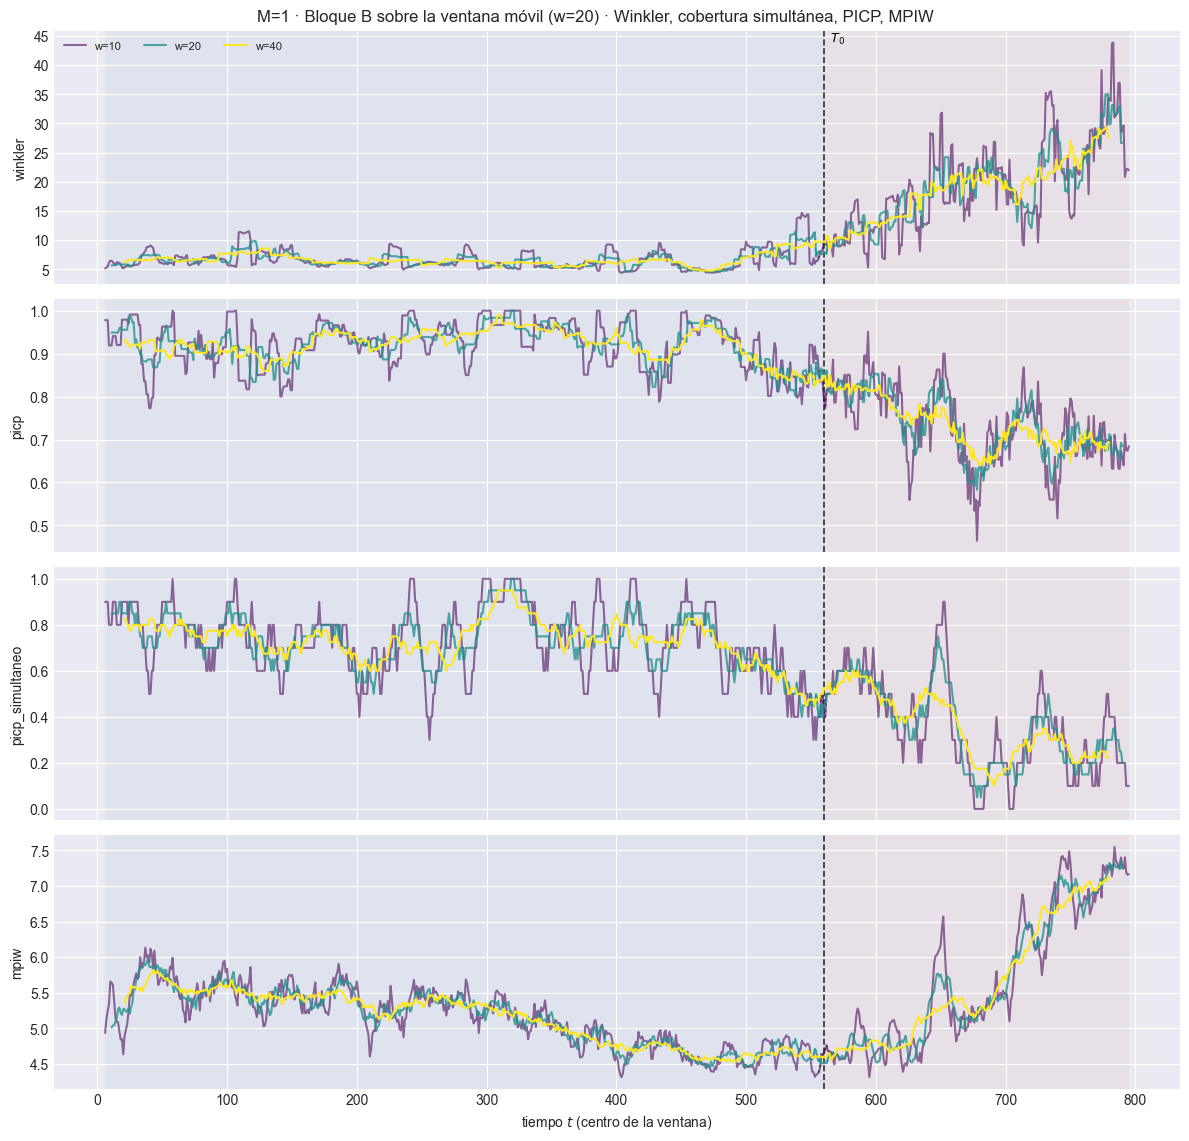

[plot_ventana_movil] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.0s  winkler: w=10 train=6.009  w=10 test=16.2  w=20 train=6.341  w=20 test=17.47  w=40 train=6.32  w=40 test=17.54
  2/4 (50.0%) t=0.0s eta=0.0s  picp: w=10 train=0.9675  w=10 test=0.777  w=20 train=0.958  w=20 test=0.776  w=40 train=0.9635  w=40 test=0.768
  3/4 (75.0%) t=0.0s eta=0.0s  picp_simultaneo: w=10 train=0.9  w=10 test=0.5  w=20 train=0.85  w=20 test=0.45  w=40 train=0.85  w=40 test=0.425
  4/4 (100.0%) t=0.1s eta=0.0s  mpiw: w=10 train=5.596  w=10 test=5.876  w=20 train=5.655  w=20 test=5.92  w=40 train=5.706  w=40 test=5.863
[plot_ventana_movil] listo: 4 pasos en 0.8s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m02\61_ventana_bloqueB.png


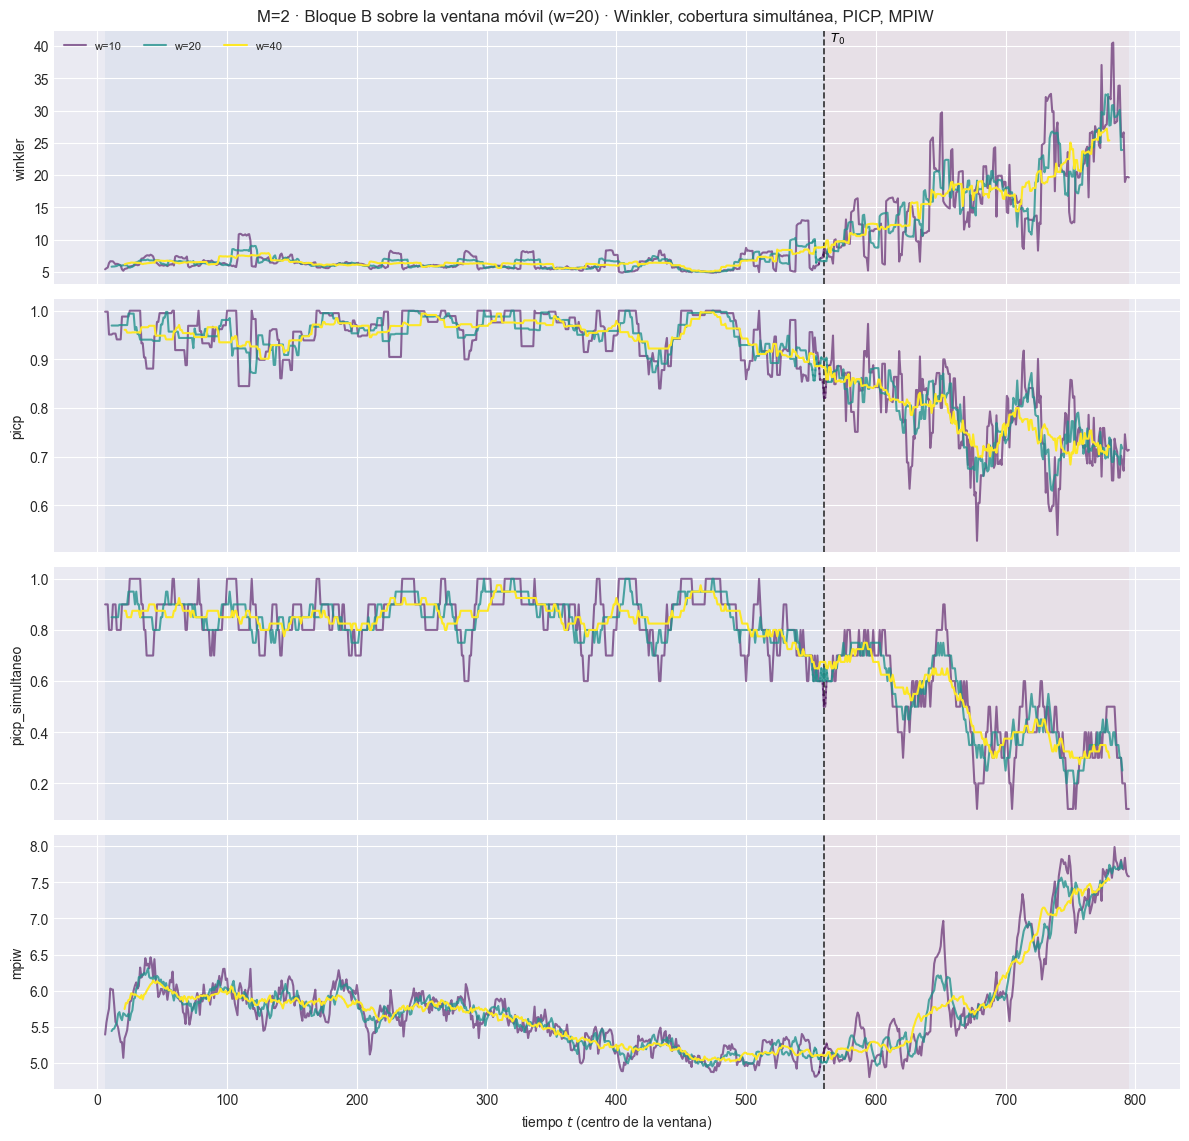

[plot_ventana_movil] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.0s  winkler: w=10 train=6.053  w=10 test=15.66  w=20 train=6.251  w=20 test=16.94  w=40 train=6.324  w=40 test=17.11
  2/4 (50.0%) t=0.0s eta=0.0s  picp: w=10 train=0.972  w=10 test=0.783  w=20 train=0.964  w=20 test=0.7895  w=40 train=0.966  w=40 test=0.7765
  3/4 (75.0%) t=0.0s eta=0.0s  picp_simultaneo: w=10 train=0.9  w=10 test=0.5  w=20 train=0.9  w=20 test=0.5  w=40 train=0.875  w=40 test=0.45
  4/4 (100.0%) t=0.1s eta=0.0s  mpiw: w=10 train=5.687  w=10 test=5.9  w=20 train=5.735  w=20 test=5.961  w=40 train=5.777  w=40 test=5.886
[plot_ventana_movil] listo: 4 pasos en 0.5s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m03\61_ventana_bloqueB.png


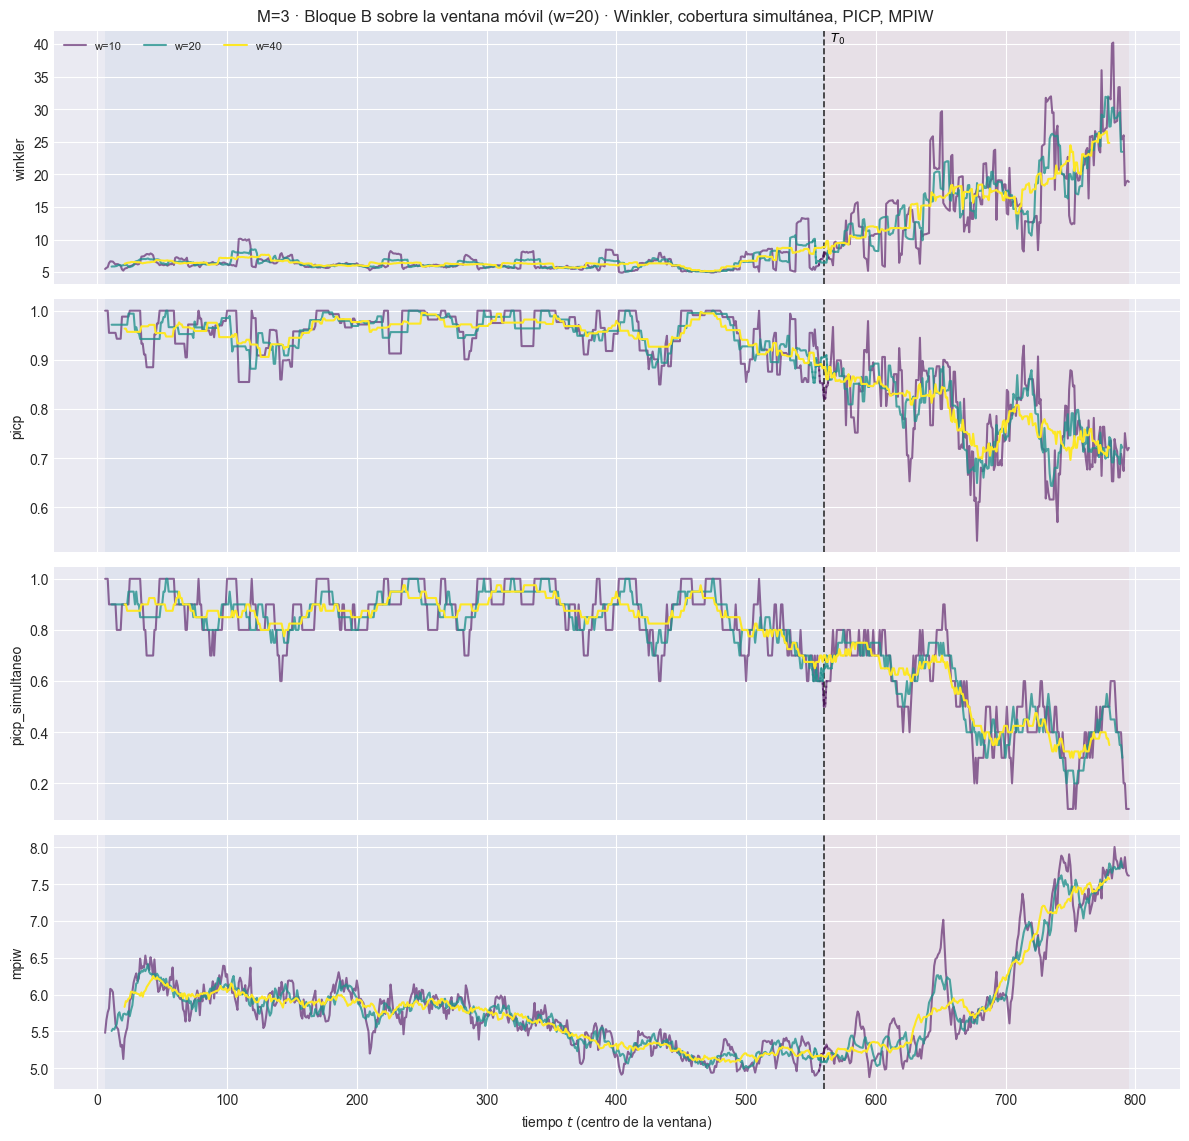

In [16]:
# Bloque B, una sola vista: Winkler, cobertura simultanea, cobertura puntual,
# MPIW. Reutiliza tablas_fun, ya calculada en §4.
for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]
    faltan = [c for c in METRICAS_B_COLS if c not in tfun.columns]
    assert not faltan, (
        f"[M={M}] faltan columnas del Bloque B: {faltan}. Revisar que "
        "ventana_movil_funcional se haya llamado con li/ls y bloque_A=True.")

    plot_ventana_movil(
        tfun, T0, METRICAS_B_COLS, tablas_por_w=e["tablas_fun"],
        title=f"M={M} · Bloque B sobre la ventana móvil (w={W_REF}) · "
              "Winkler, cobertura simultánea, PICP, MPIW",
        save_path=str(e["paths"]["out_report"] / "61_ventana_bloqueB.png"),
        verbose=True)
    plt.show()

    assert (tfun["picp_simultaneo"] <= tfun["picp"] + 1e-9).all(), (
        f"[M={M}] la cobertura simultanea supero a la puntual en alguna "
        "ventana: no puede pasar por definicion.")


## 6. Muestra de predicciones

Dos vistas: un extracto regular del bloque de **prueba** (para no mezclar con
in-sample), y las ventanas con **peor** valor de `METRICA_PEORES` ([CONFIG]).
En la segunda se agrega la curva **anterior** ($t-1$, gris punteada): es el
primer diagnóstico de POR QUÉ el modelo se equivocó -¿la curva de partida ya
era atípica?-.

[plot_extractos_curvas] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.0s  t=561 [test] cob=0.640 rmse=2.077
  2/8 (25.0%) t=0.0s eta=0.0s  t=591 [test] cob=1.000 rmse=0.615
  3/8 (37.5%) t=0.0s eta=0.0s  t=621 [test] cob=0.970 rmse=0.8576
  4/8 (50.0%) t=0.0s eta=0.0s  t=651 [test] cob=1.000 rmse=2.297
  5/8 (62.5%) t=0.0s eta=0.0s  t=681 [test] cob=0.000 rmse=3.456
  6/8 (75.0%) t=0.0s eta=0.0s  t=711 [test] cob=0.950 rmse=3.415
  7/8 (87.5%) t=0.0s eta=0.0s  t=741 [test] cob=0.000 rmse=3.684
  8/8 (100.0%) t=0.0s eta=0.0s  t=771 [test] cob=0.980 rmse=3.478
[plot_extractos_curvas] listo: 8 pasos en 0.9s  cob media train=nan test=0.693 (nominal 0.95)


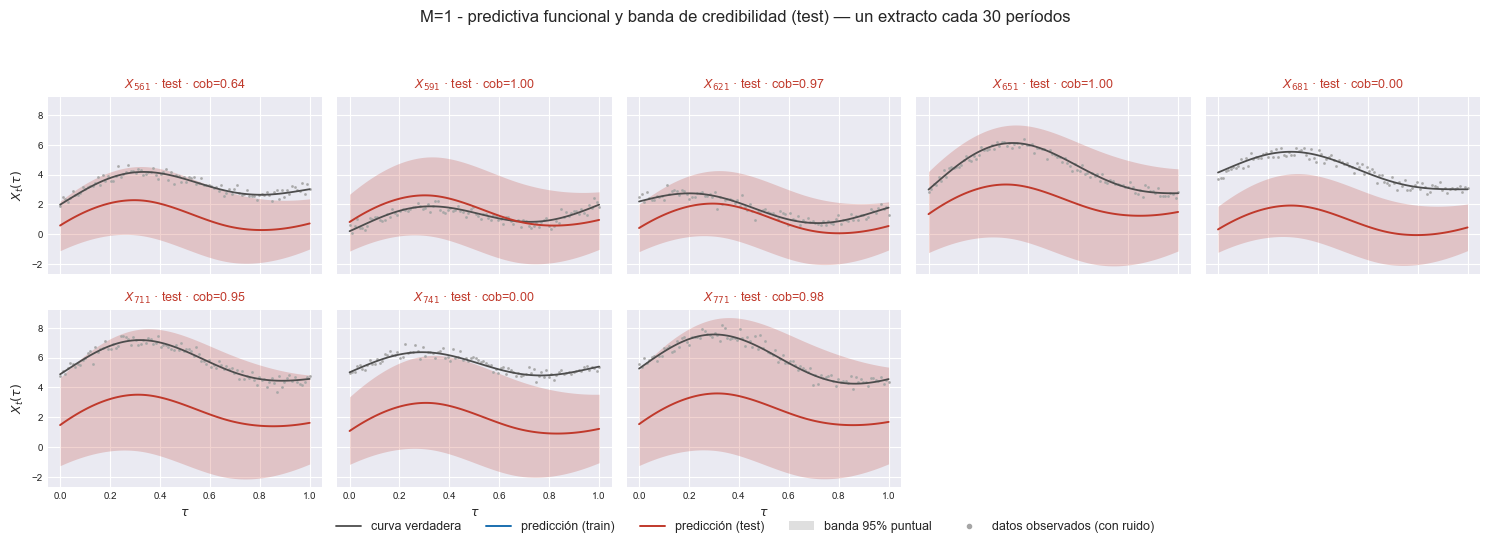

[plot_extractos_curvas] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.0s  t=561 [test] cob=0.810 rmse=2.127
  2/8 (25.0%) t=0.0s eta=0.0s  t=591 [test] cob=1.000 rmse=0.599
  3/8 (37.5%) t=0.0s eta=0.0s  t=621 [test] cob=1.000 rmse=0.85
  4/8 (50.0%) t=0.0s eta=0.0s  t=651 [test] cob=1.000 rmse=2.538
  5/8 (62.5%) t=0.0s eta=0.0s  t=681 [test] cob=0.000 rmse=3.438
  6/8 (75.0%) t=0.0s eta=0.0s  t=711 [test] cob=1.000 rmse=3.588
  7/8 (87.5%) t=0.0s eta=0.0s  t=741 [test] cob=0.110 rmse=3.612
  8/8 (100.0%) t=0.0s eta=0.0s  t=771 [test] cob=1.000 rmse=3.477
[plot_extractos_curvas] listo: 8 pasos en 0.9s  cob media train=nan test=0.740 (nominal 0.95)


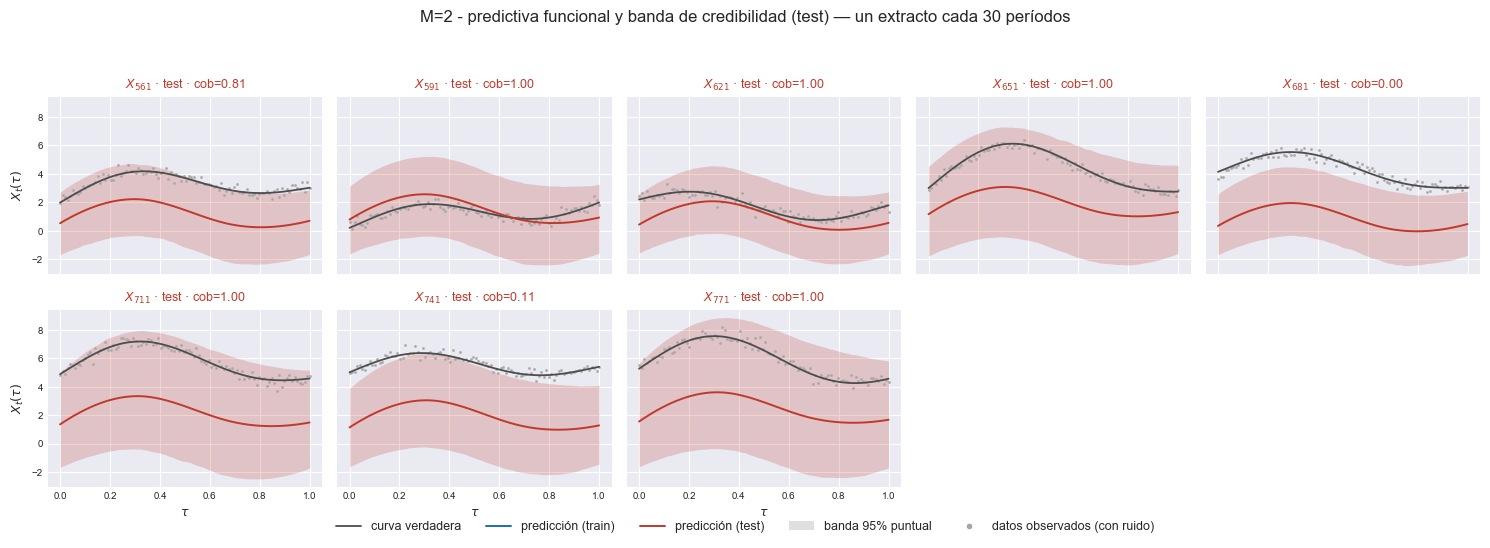

[plot_extractos_curvas] inicio (8 pasos)
  1/8 (12.5%) t=0.0s eta=0.0s  t=561 [test] cob=0.660 rmse=2.15
  2/8 (25.0%) t=0.0s eta=0.0s  t=591 [test] cob=1.000 rmse=0.5903
  3/8 (37.5%) t=0.0s eta=0.0s  t=621 [test] cob=1.000 rmse=0.8725
  4/8 (50.0%) t=0.0s eta=0.0s  t=651 [test] cob=1.000 rmse=2.354
  5/8 (62.5%) t=0.0s eta=0.0s  t=681 [test] cob=0.000 rmse=3.461
  6/8 (75.0%) t=0.0s eta=0.0s  t=711 [test] cob=1.000 rmse=3.457
  7/8 (87.5%) t=0.0s eta=0.0s  t=741 [test] cob=0.000 rmse=3.684
  8/8 (100.0%) t=0.0s eta=0.0s  t=771 [test] cob=1.000 rmse=3.374
[plot_extractos_curvas] listo: 8 pasos en 0.9s  cob media train=nan test=0.708 (nominal 0.95)


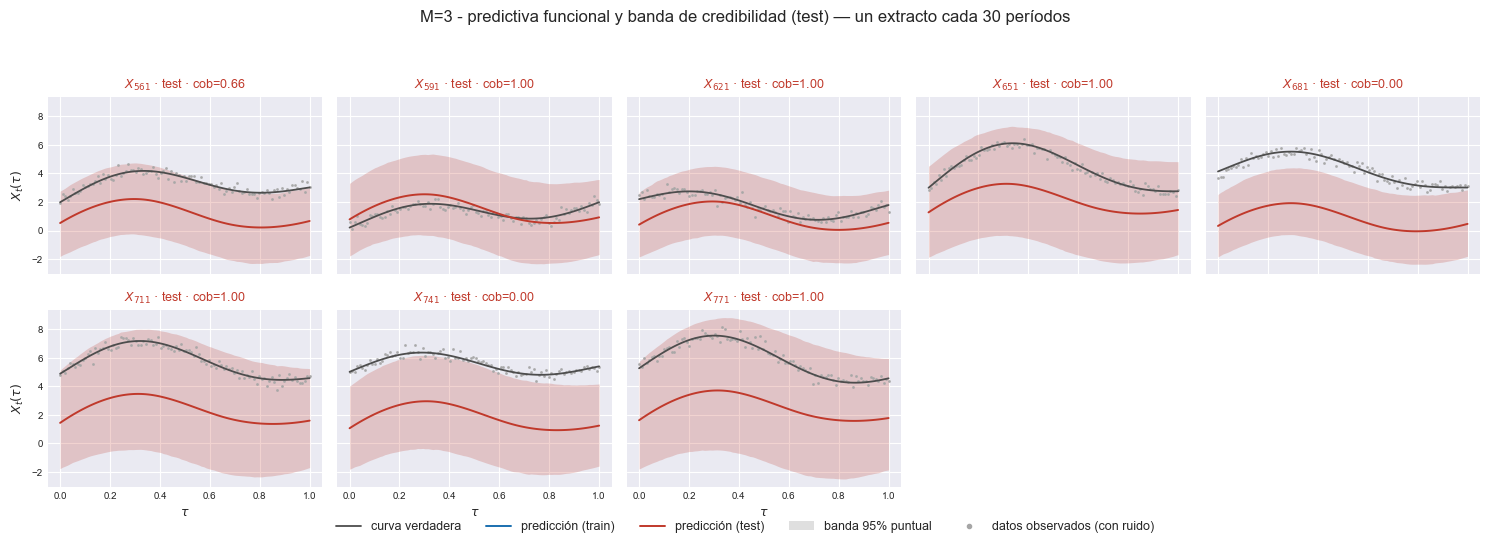

In [17]:
# Extractos regulares, SOLO del bloque de prueba.
mask_test = ~es_train
for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_true_ev[mask_test], e["X_pred"][mask_test], e["li_f"][mask_test],
        e["ls_f"][mask_test], grilla, T0, t=t_orig[mask_test],
        cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev[mask_test],
        title=f"M={M} - predictiva funcional y banda de credibilidad (test)",
        save_path=str(e["paths"]["out_report"] / "54_extractos_curvas_test.png"),
        verbose=True)
    plt.show()


[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=557 [train] cob=0.580 rmse=2.458
  2/7 (28.6%) t=0.0s eta=0.0s  t=558 [train] cob=1.000 rmse=0.9524
  3/7 (42.9%) t=0.0s eta=0.0s  t=559 [train] cob=0.700 rmse=2.338
  4/7 (57.1%) t=0.0s eta=0.0s  t=560 [train] cob=1.000 rmse=1.296
  5/7 (71.4%) t=0.0s eta=0.0s  t=561 [test] cob=0.640 rmse=2.077
  6/7 (85.7%) t=0.0s eta=0.0s  t=562 [test] cob=0.460 rmse=2.717
  7/7 (100.0%) t=0.0s eta=0.0s  t=563 [test] cob=1.000 rmse=0.9732
[plot_extractos_curvas] listo: 7 pasos en 0.8s  cob media train=0.820 test=0.700 (nominal 0.95)


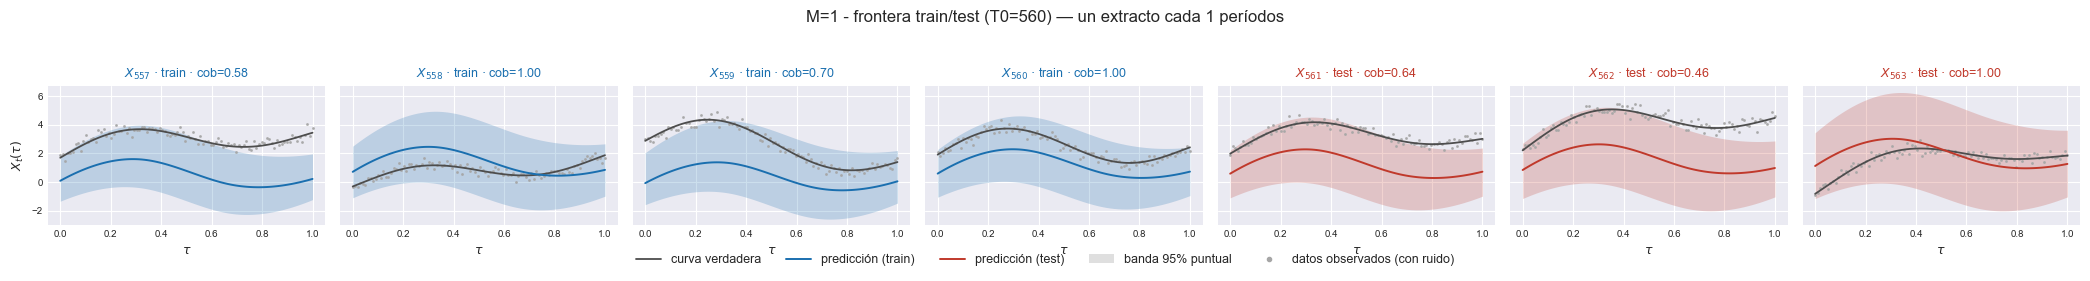

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=557 [train] cob=0.580 rmse=2.479
  2/7 (28.6%) t=0.0s eta=0.0s  t=558 [train] cob=1.000 rmse=0.9673
  3/7 (42.9%) t=0.0s eta=0.0s  t=559 [train] cob=0.670 rmse=2.284
  4/7 (57.1%) t=0.0s eta=0.0s  t=560 [train] cob=1.000 rmse=1.286
  5/7 (71.4%) t=0.0s eta=0.0s  t=561 [test] cob=0.810 rmse=2.127
  6/7 (85.7%) t=0.0s eta=0.0s  t=562 [test] cob=0.520 rmse=2.761
  7/7 (100.0%) t=0.0s eta=0.0s  t=563 [test] cob=1.000 rmse=0.9804
[plot_extractos_curvas] listo: 7 pasos en 0.8s  cob media train=0.812 test=0.777 (nominal 0.95)


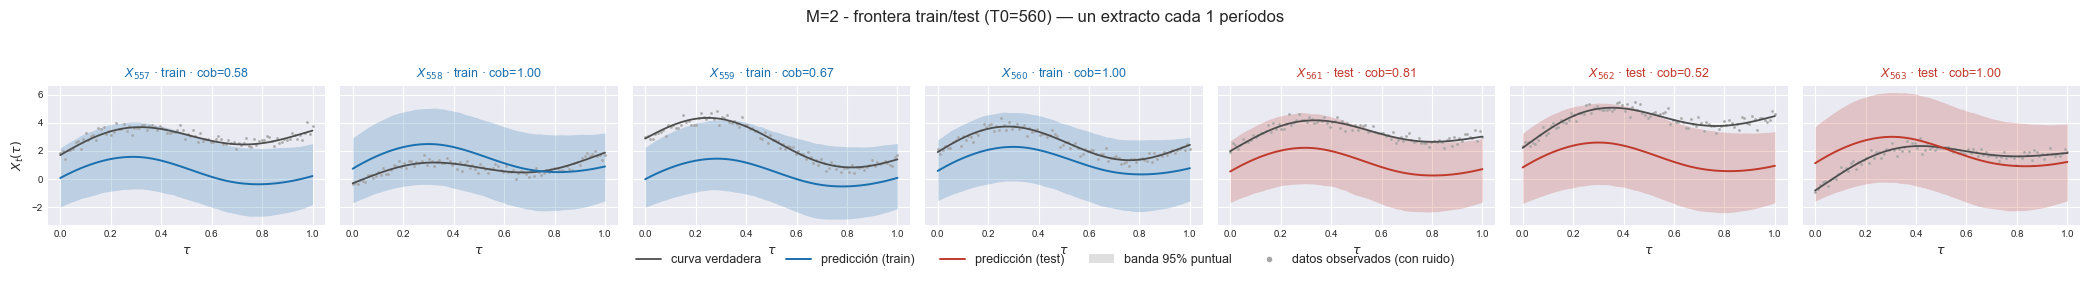

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=557 [train] cob=0.730 rmse=2.41
  2/7 (28.6%) t=0.0s eta=0.0s  t=558 [train] cob=1.000 rmse=0.9614
  3/7 (42.9%) t=0.0s eta=0.0s  t=559 [train] cob=0.610 rmse=2.314
  4/7 (57.1%) t=0.0s eta=0.0s  t=560 [train] cob=1.000 rmse=1.29
  5/7 (71.4%) t=0.0s eta=0.0s  t=561 [test] cob=0.660 rmse=2.15
  6/7 (85.7%) t=0.0s eta=0.0s  t=562 [test] cob=0.530 rmse=2.762
  7/7 (100.0%) t=0.0s eta=0.0s  t=563 [test] cob=1.000 rmse=0.9255
[plot_extractos_curvas] listo: 7 pasos en 0.7s  cob media train=0.835 test=0.730 (nominal 0.95)


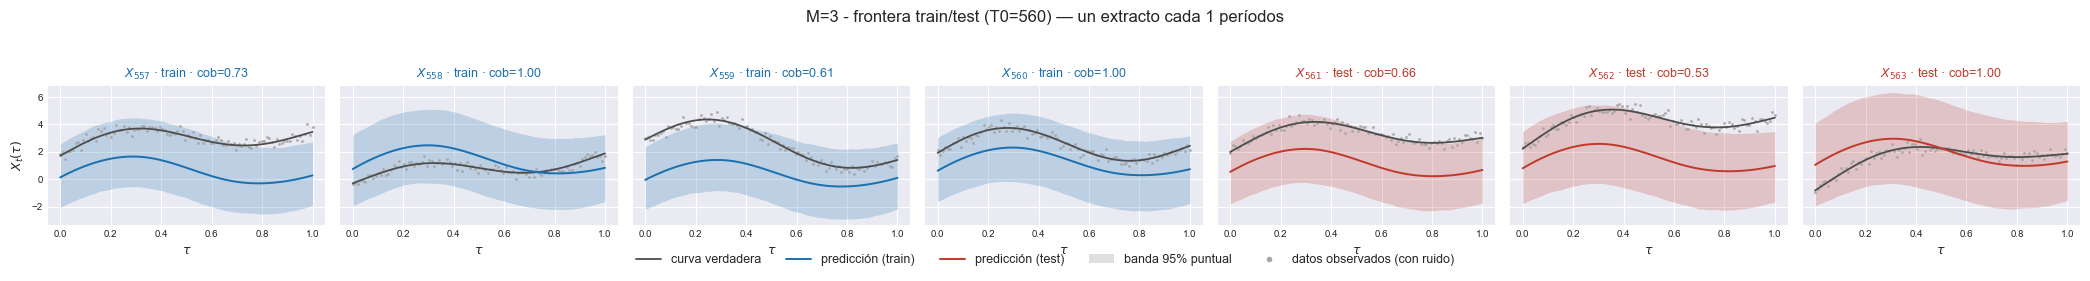

In [18]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
# Es donde se ve, curva a curva, si la banda se ensancha al salir de muestra.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_true_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel],
        grilla, T0, t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL,
        X_obs=X_obs_ev[sel],
        title=f"M={M} - frontera train/test (T0={T0})",
        save_path=str(e["paths"]["out_report"] / "55_extractos_frontera.png"),
        verbose=True)
    plt.show()

[M=1] peores 5 ventanas por rmse_f (w=20, sólo test, sin cruzar T0):
    t=[779, 798]  rmse_f=3.672439
    t=[770, 789]  rmse_f=3.662849
    t=[774, 793]  rmse_f=3.636841
    t=[773, 792]  rmse_f=3.628204
    t=[777, 796]  rmse_f=3.610304


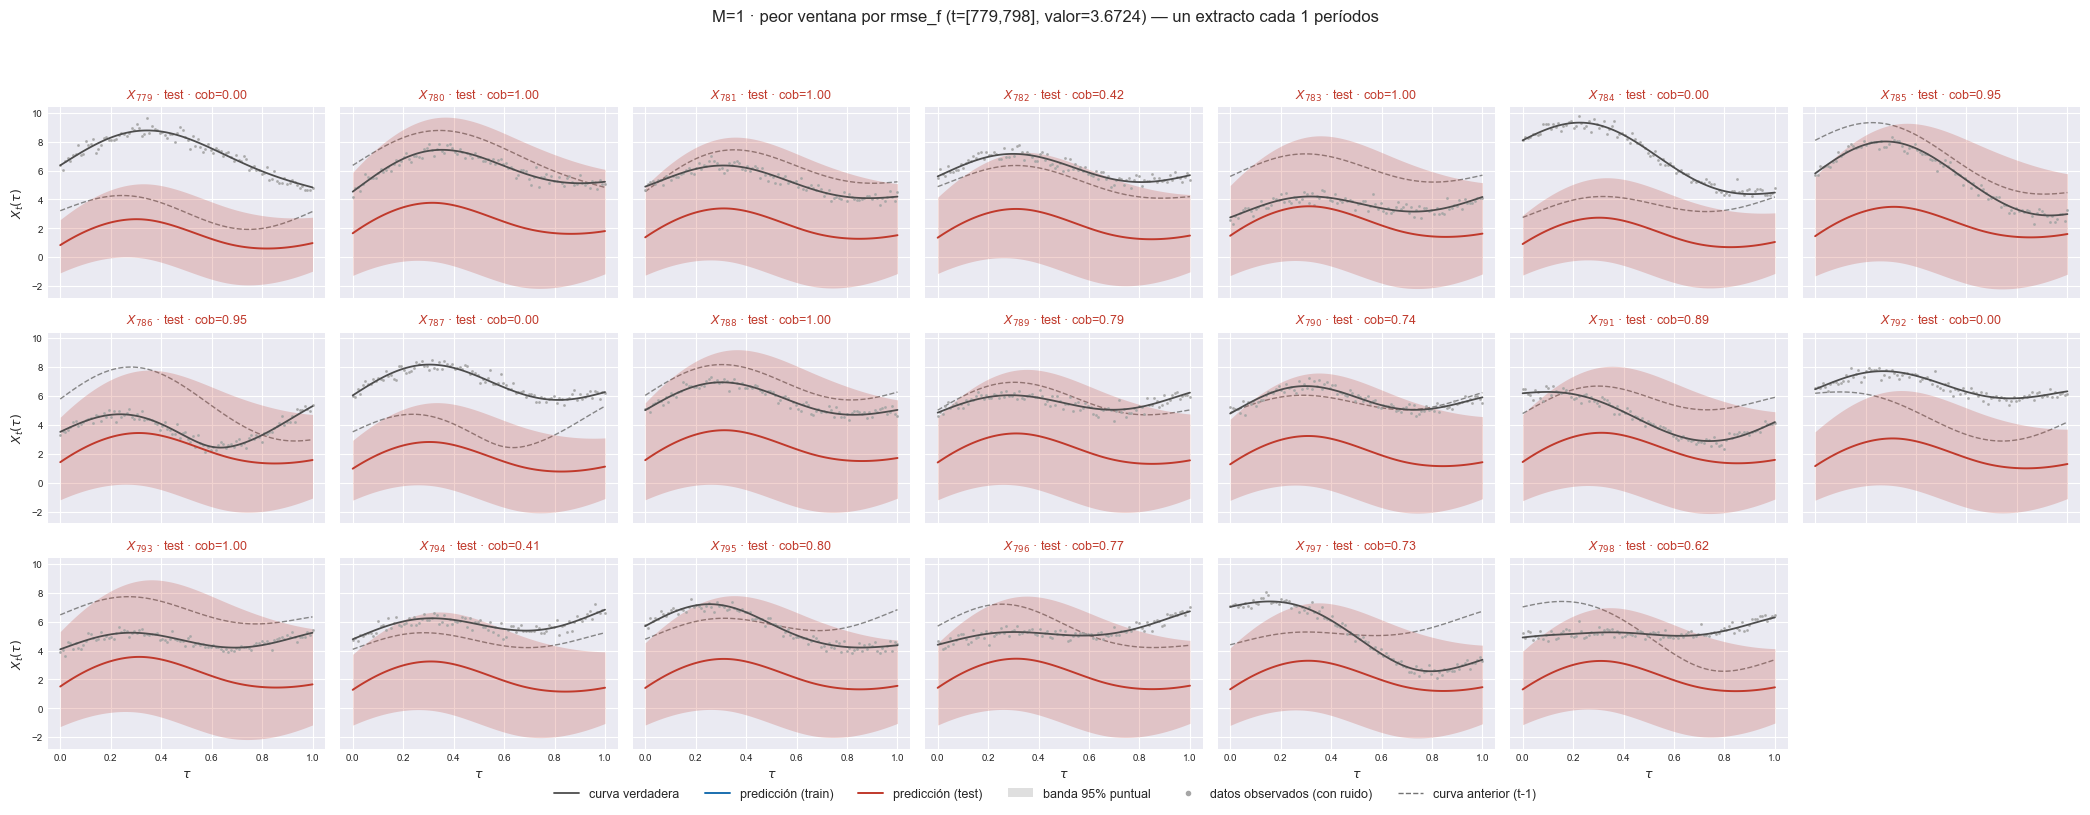

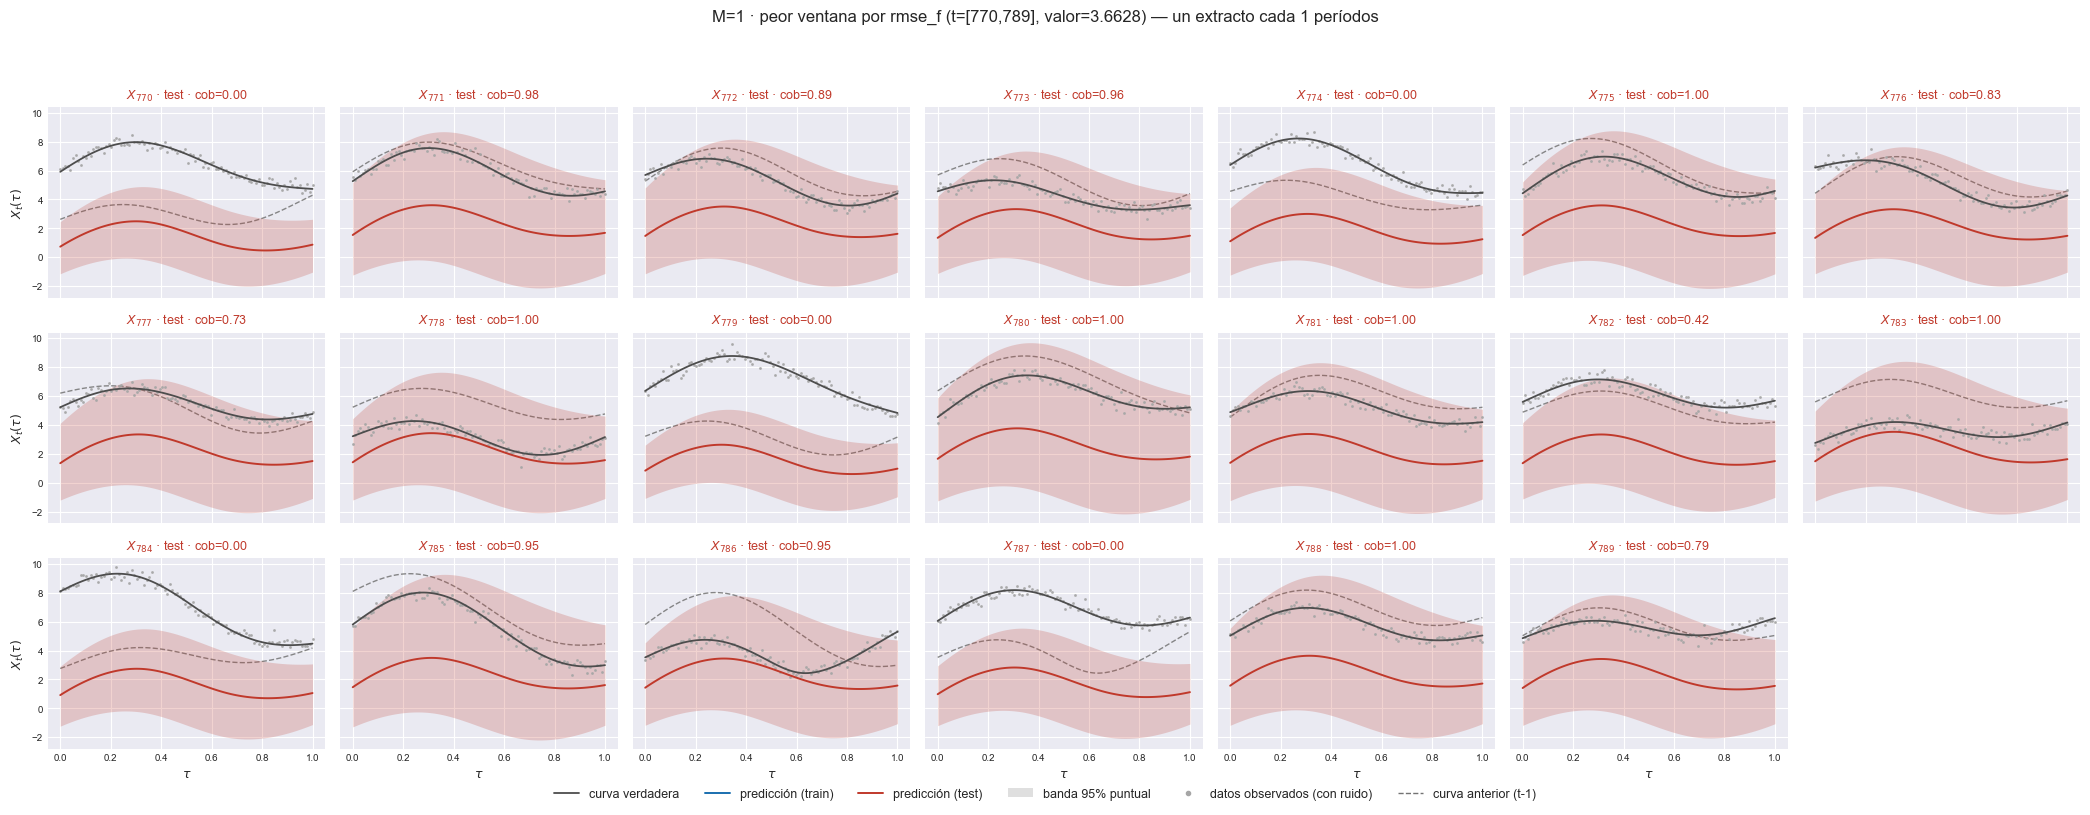

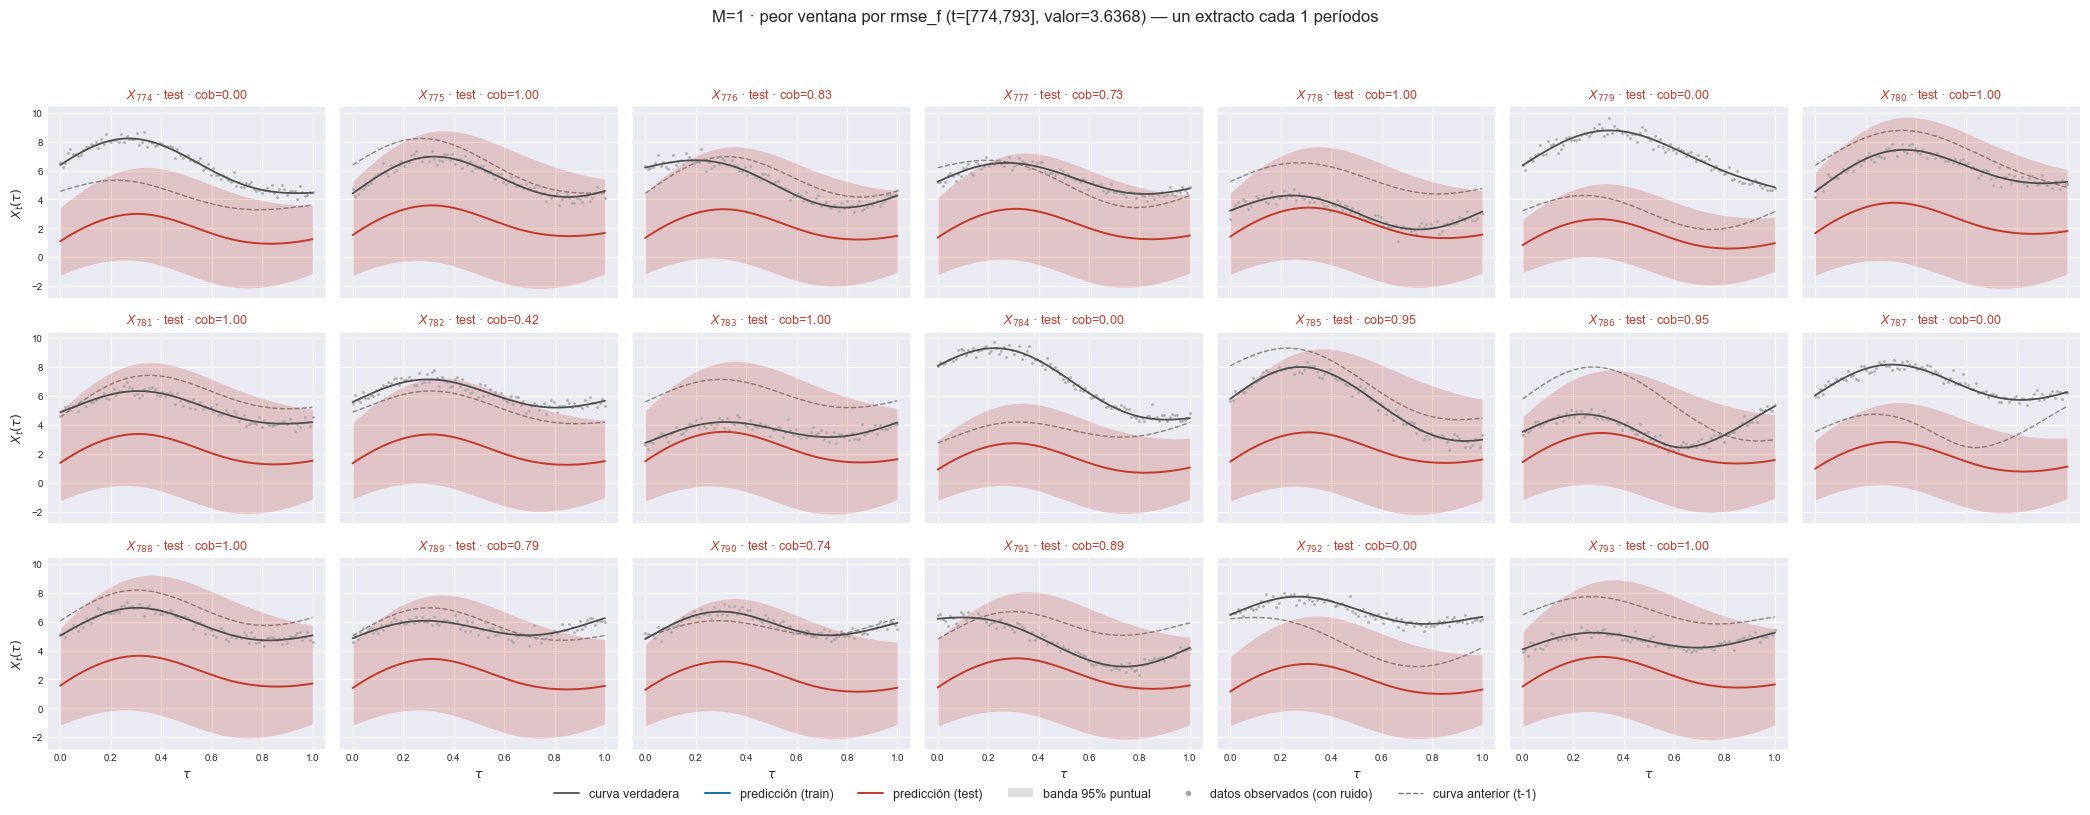

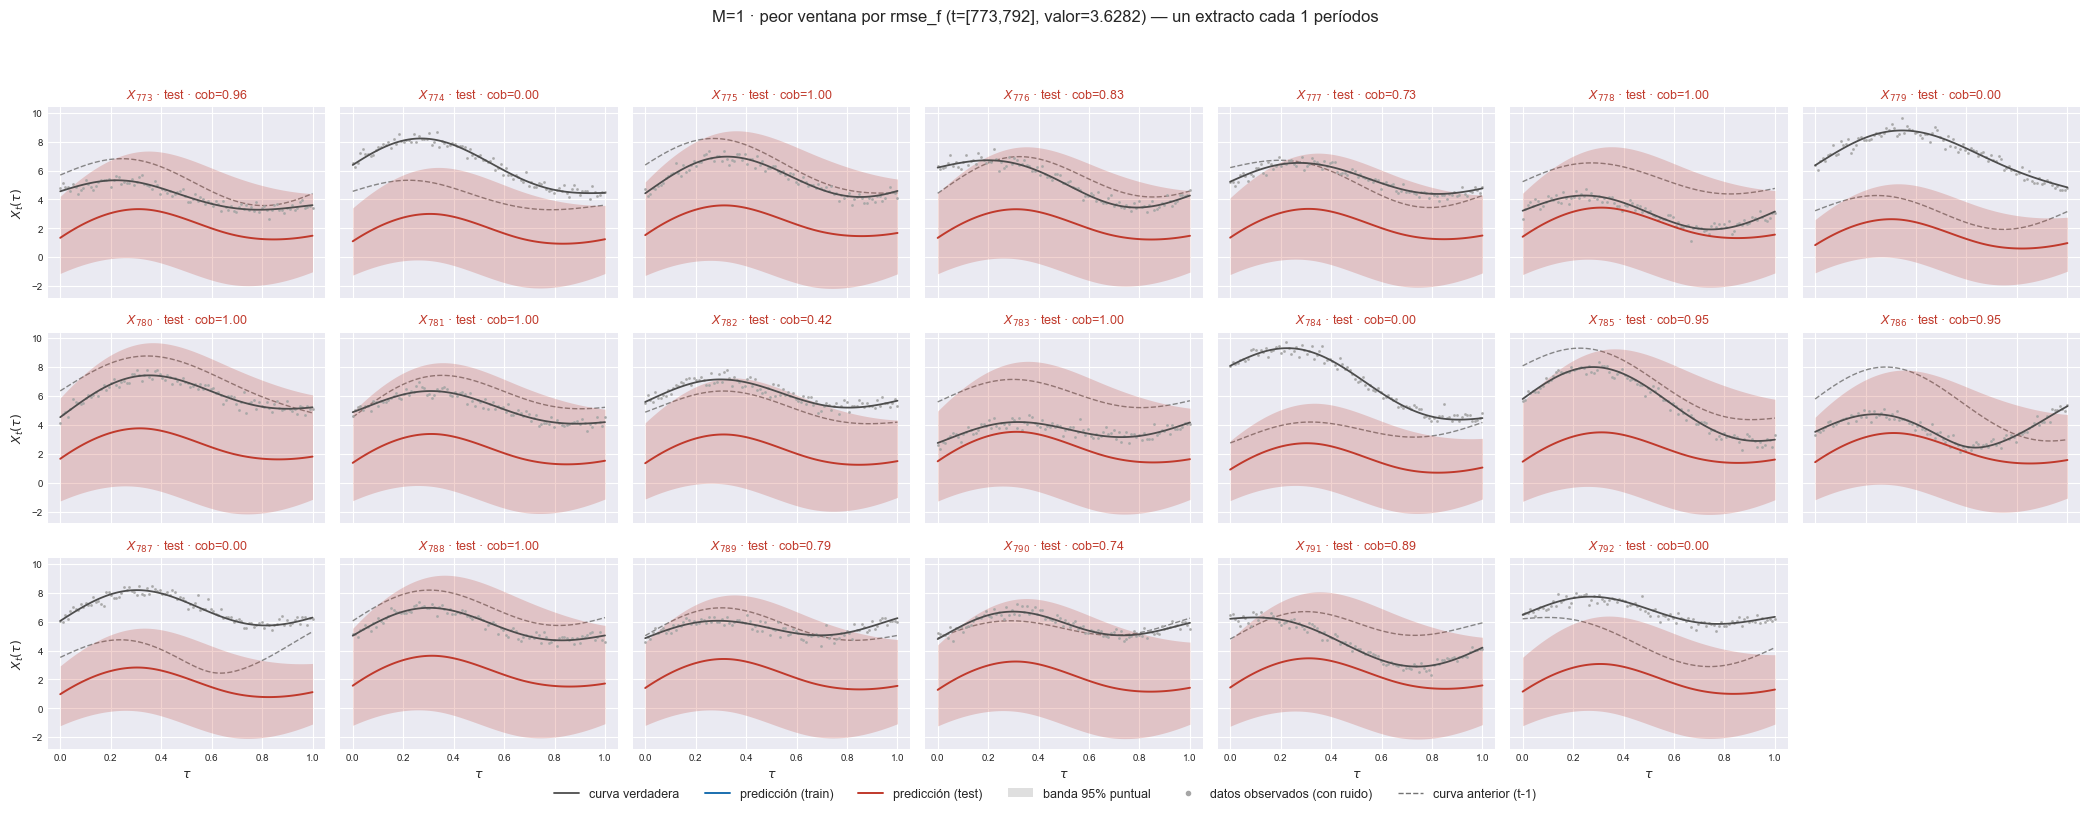

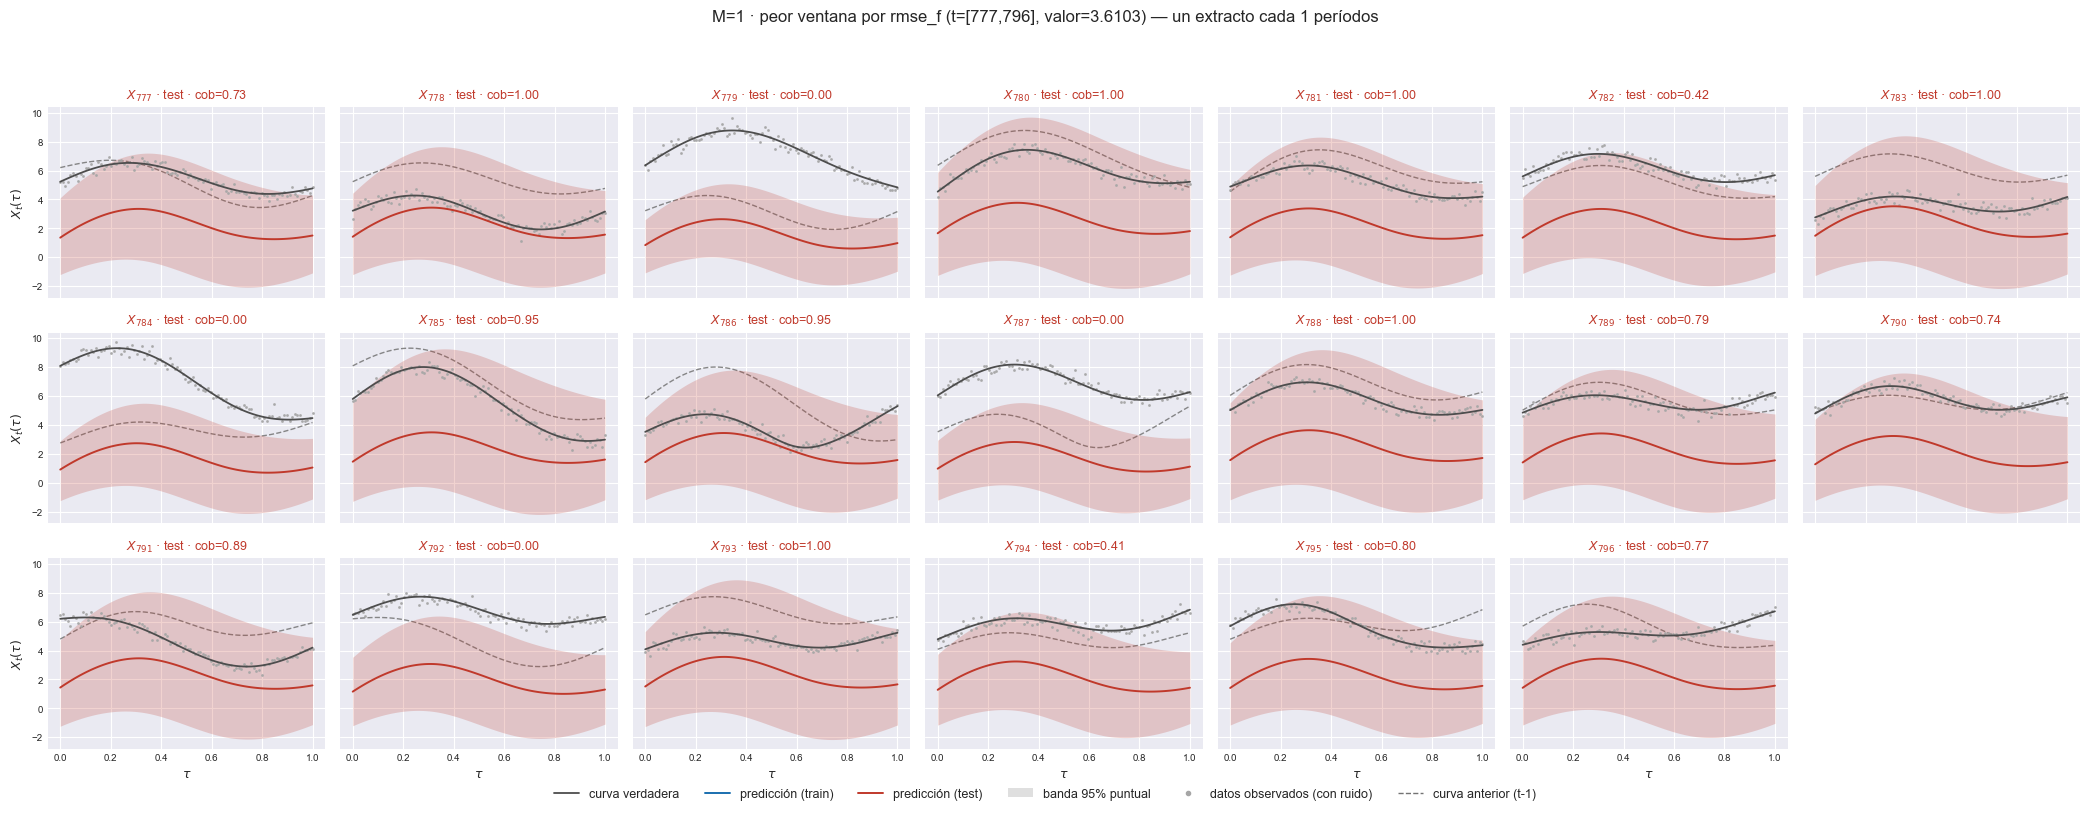

[M=2] peores 5 ventanas por rmse_f (w=20, sólo test, sin cruzar T0):
    t=[770, 789]  rmse_f=3.673242
    t=[779, 798]  rmse_f=3.672144
    t=[774, 793]  rmse_f=3.639680
    t=[773, 792]  rmse_f=3.637574
    t=[777, 796]  rmse_f=3.613300


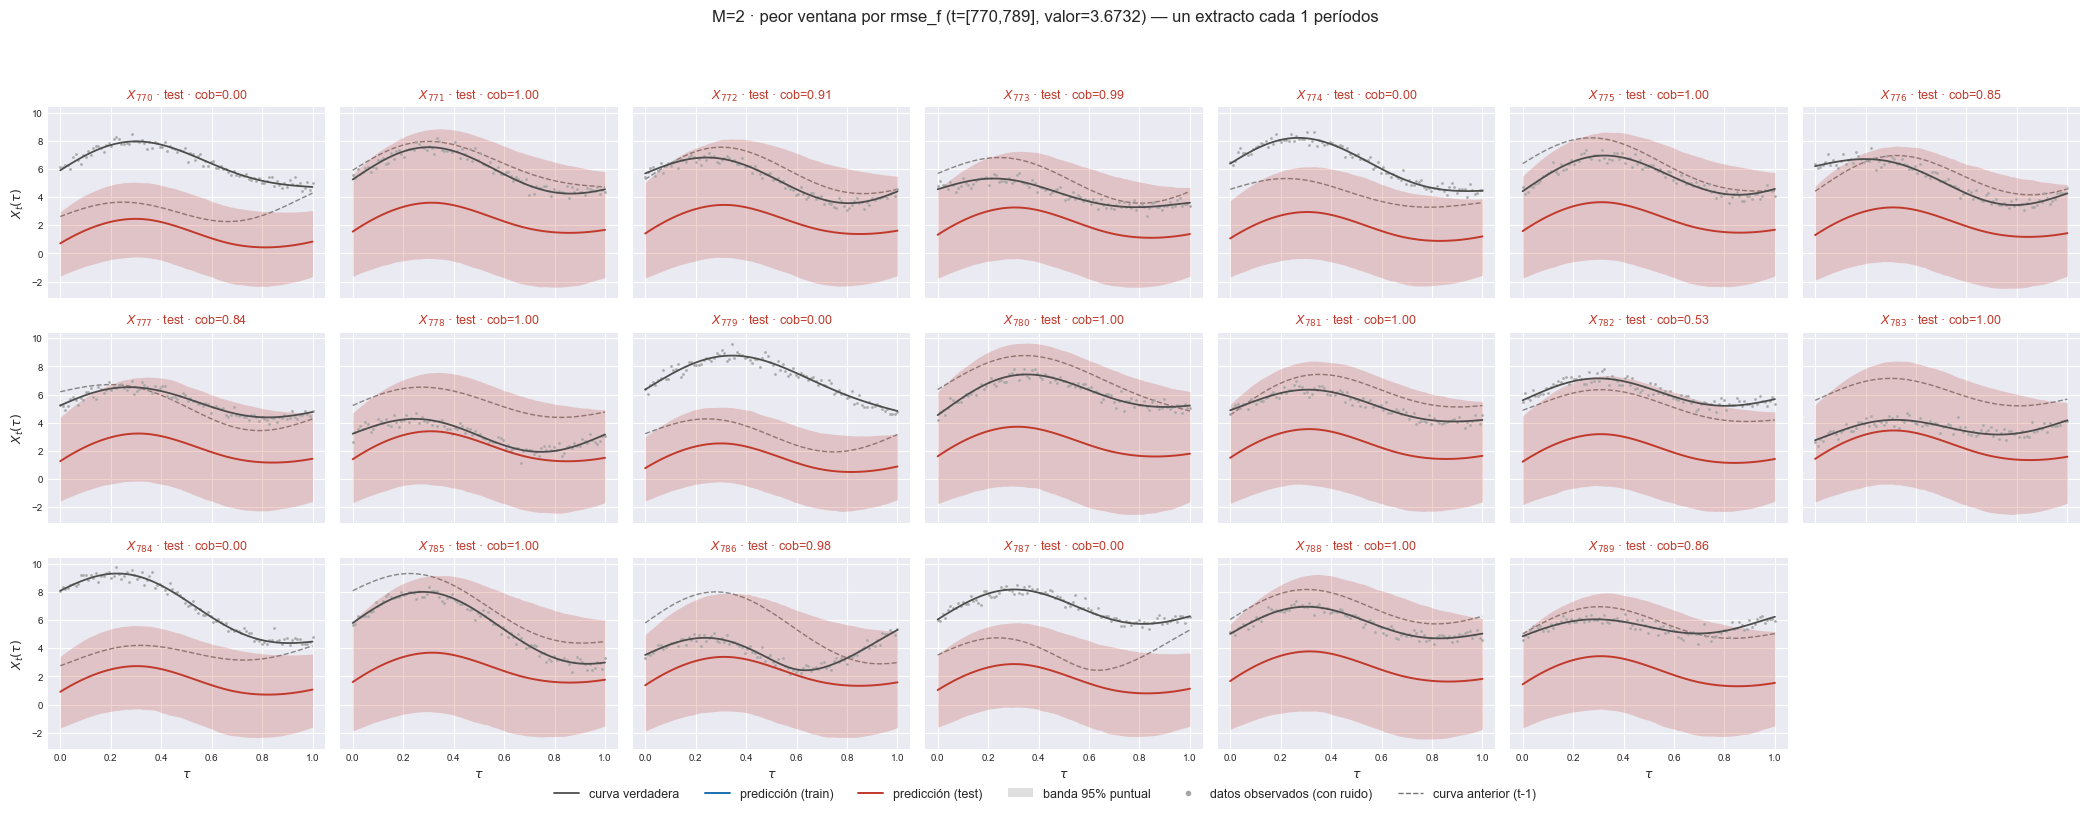

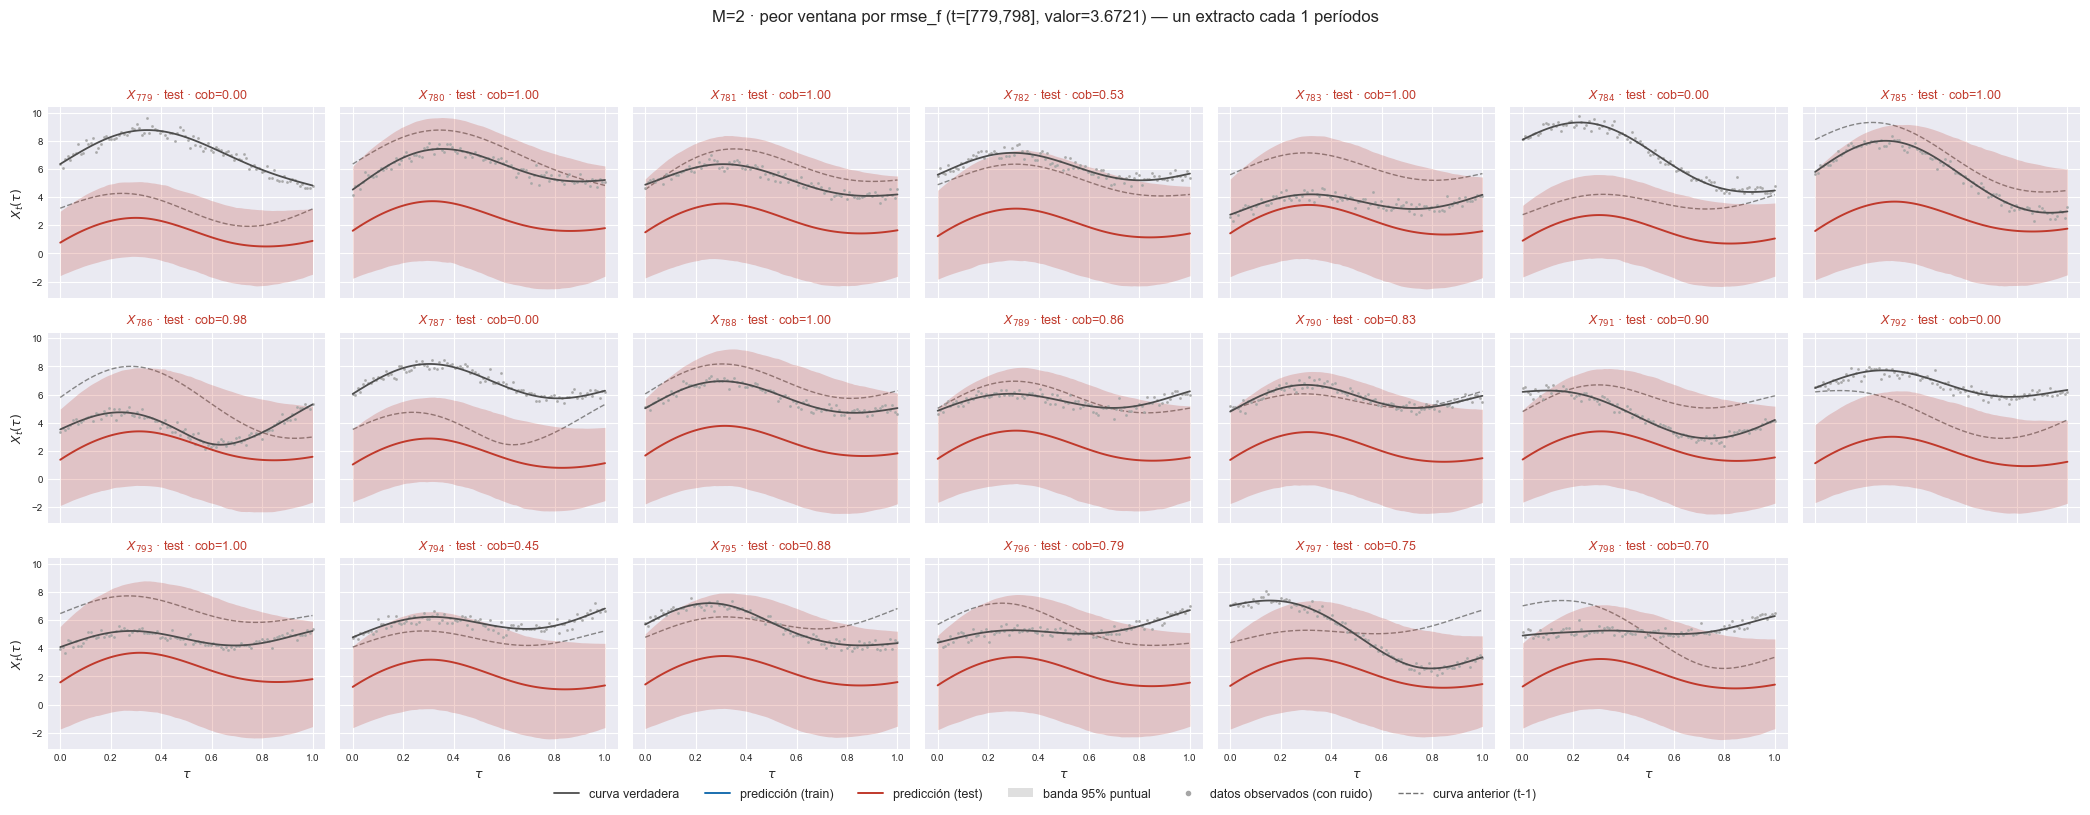

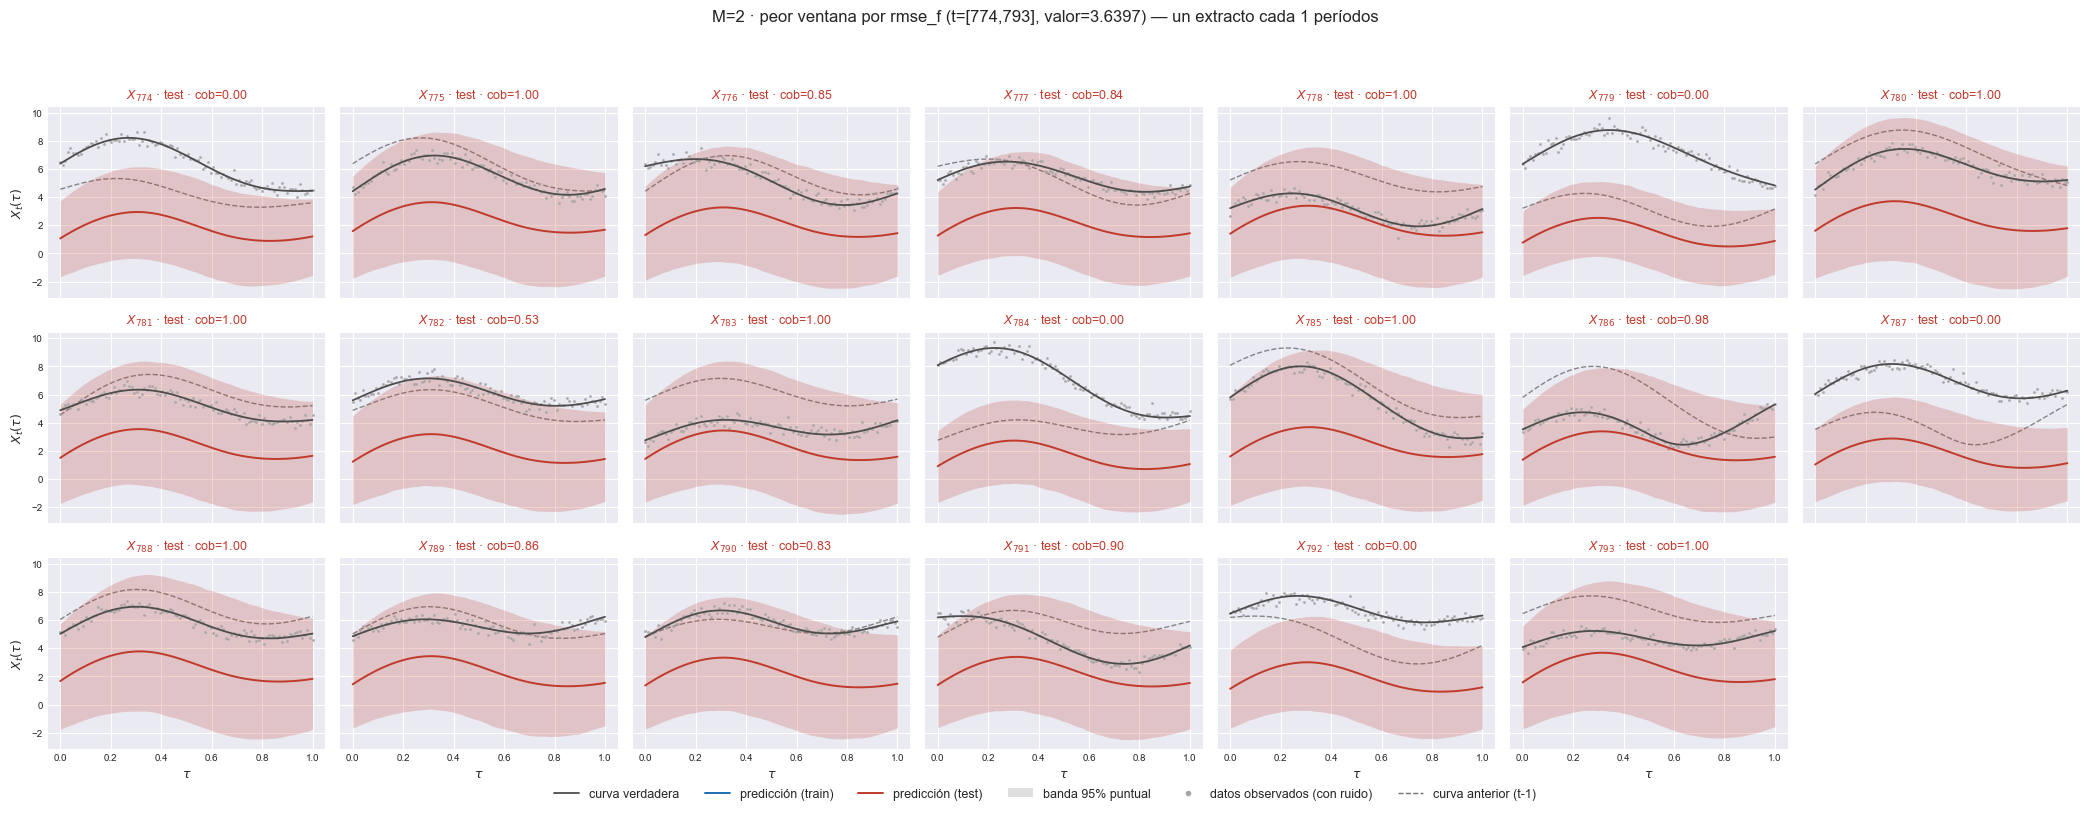

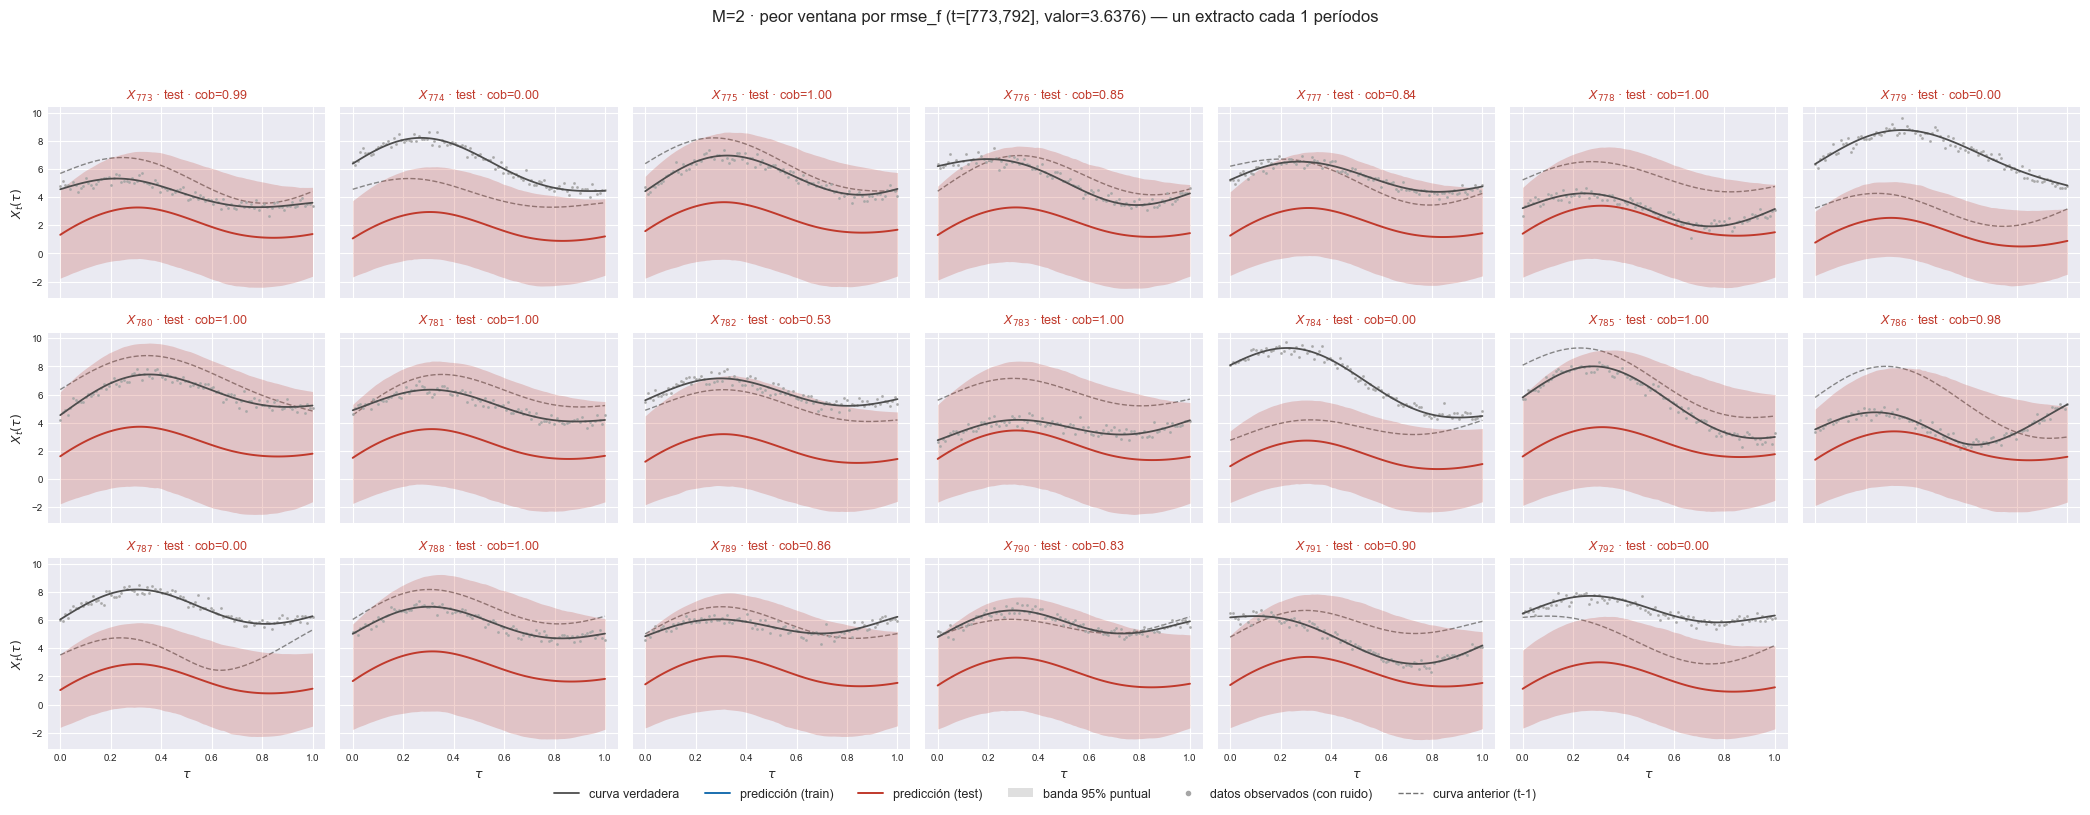

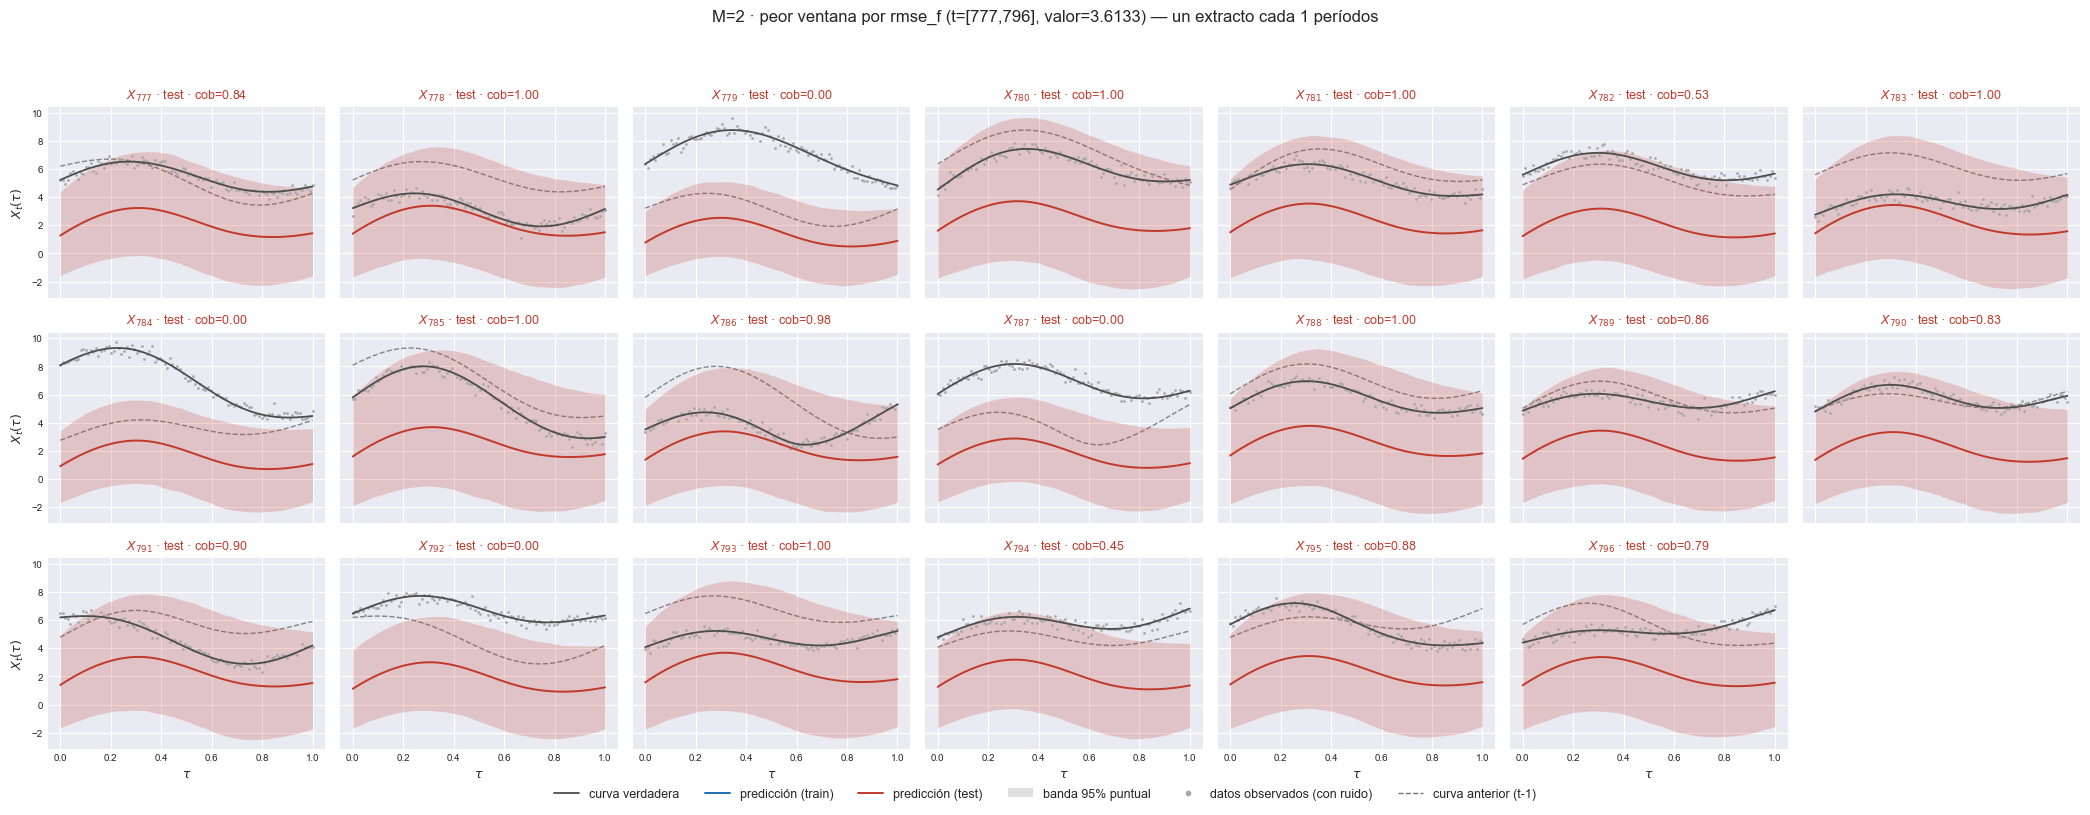

[M=3] peores 5 ventanas por rmse_f (w=20, sólo test, sin cruzar T0):
    t=[779, 798]  rmse_f=3.677313
    t=[770, 789]  rmse_f=3.668767
    t=[774, 793]  rmse_f=3.643573
    t=[773, 792]  rmse_f=3.636507
    t=[777, 796]  rmse_f=3.622453


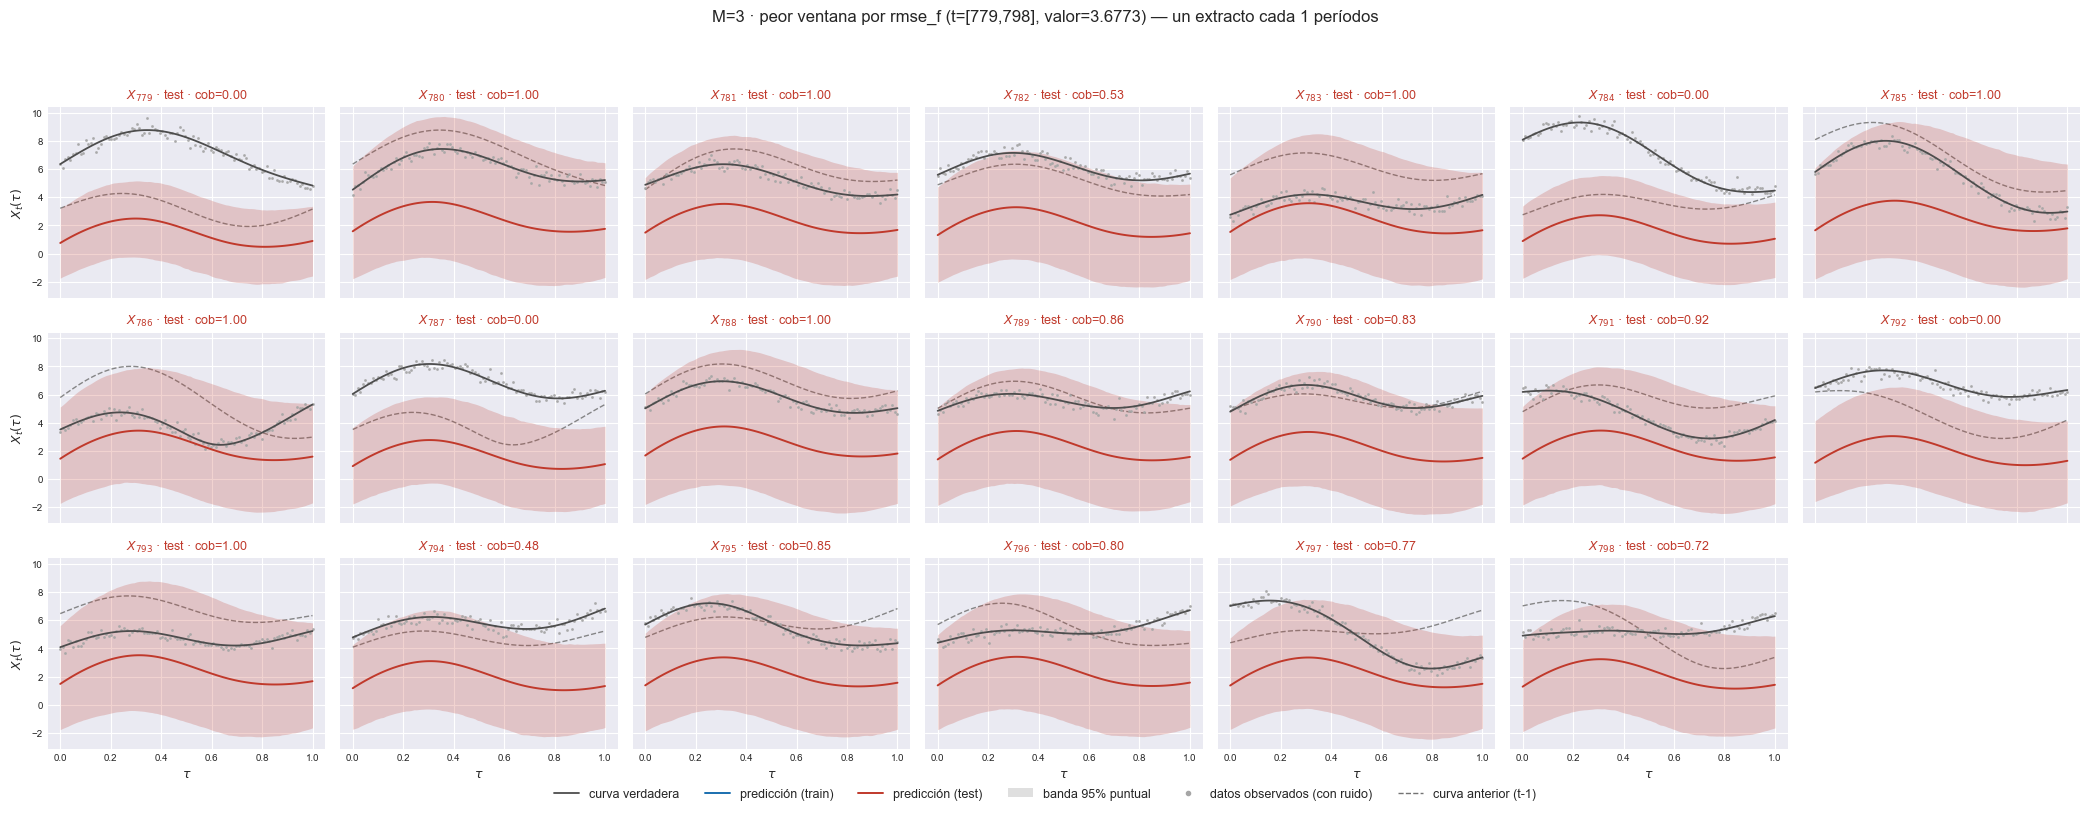

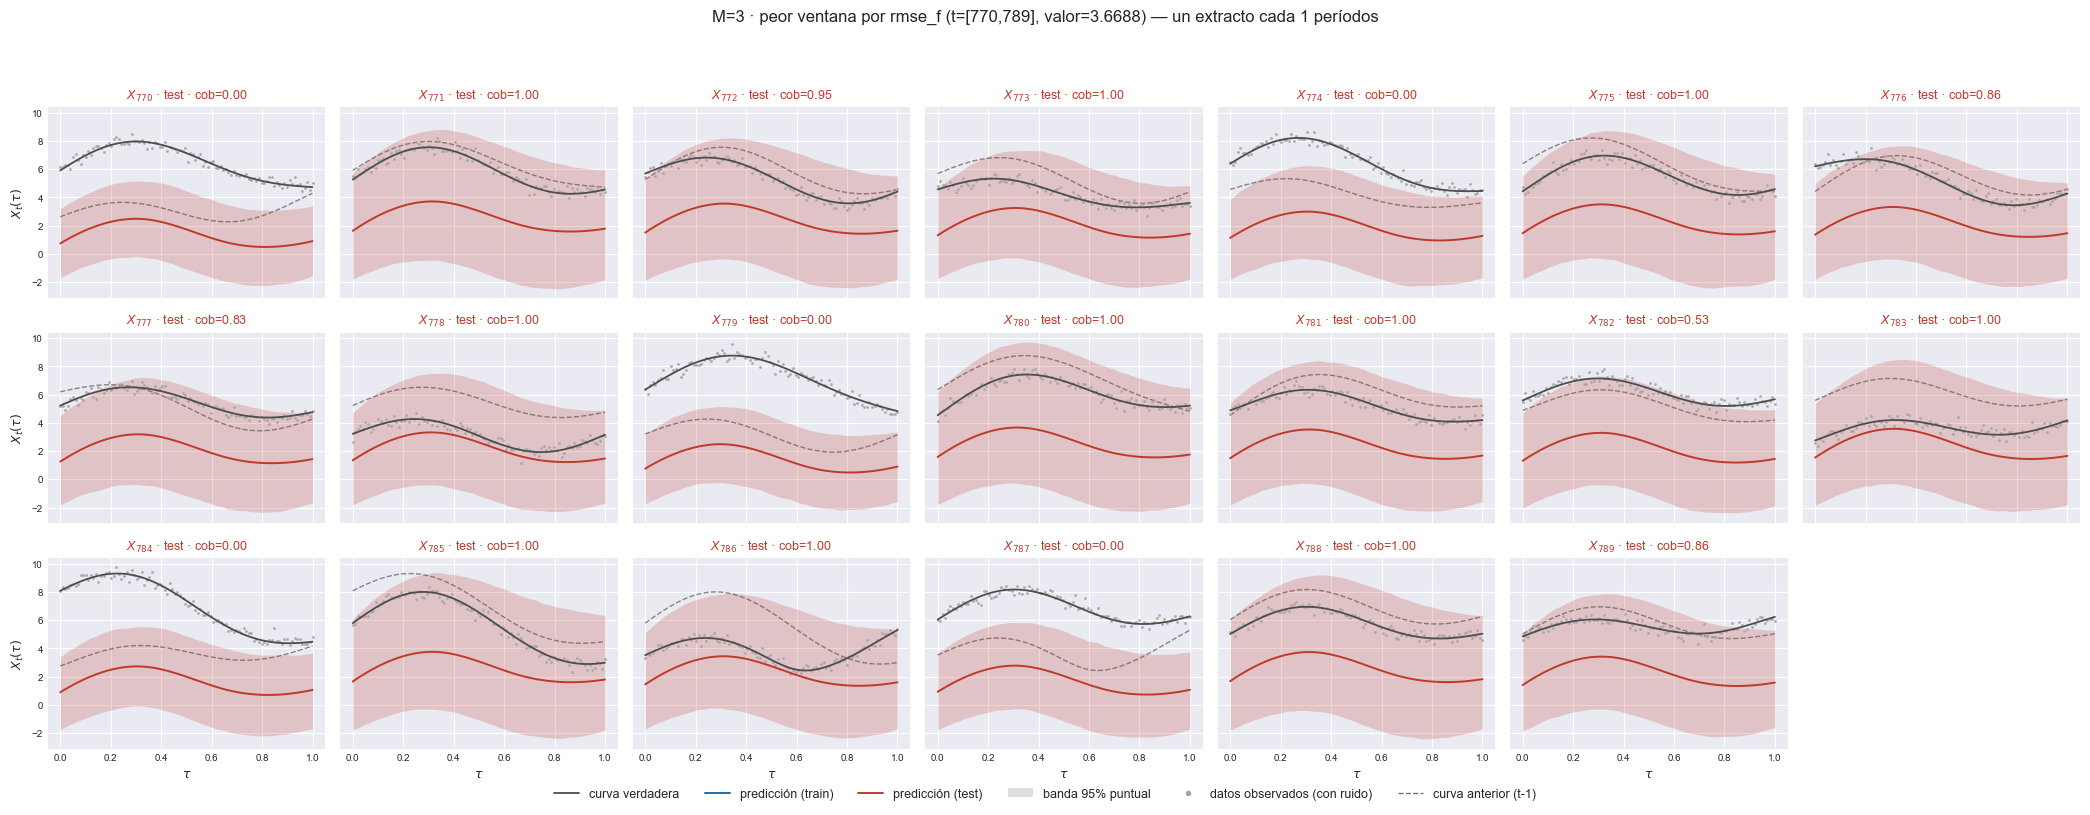

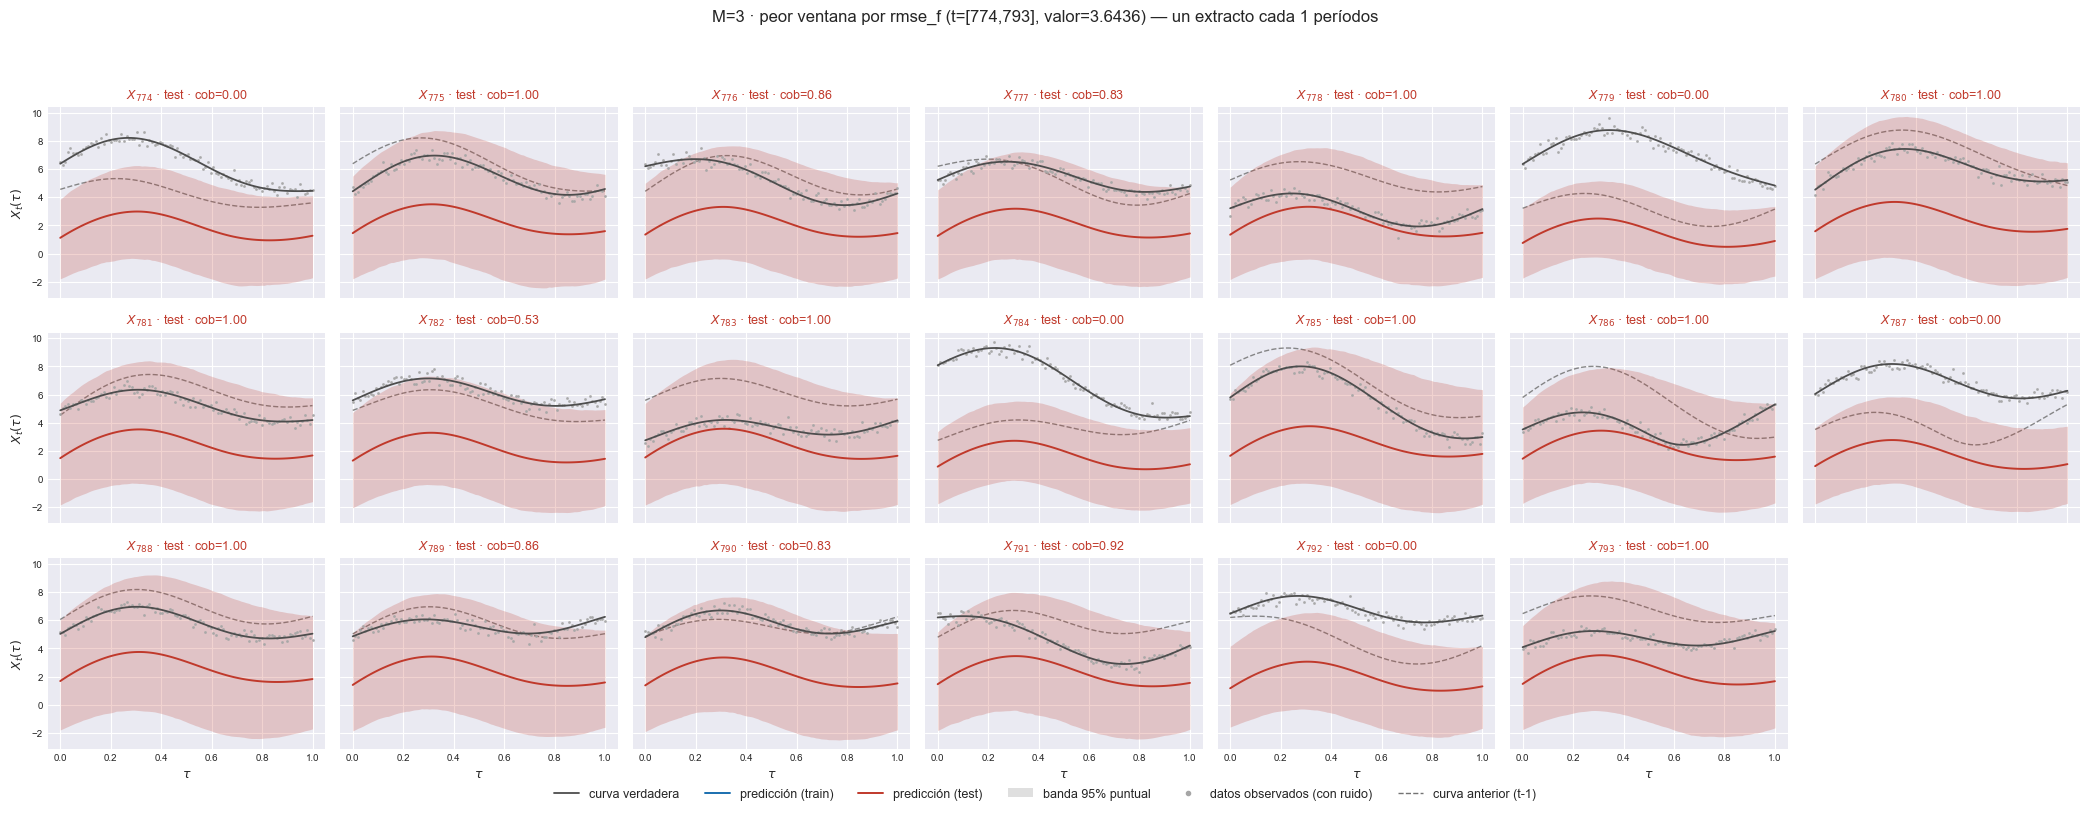

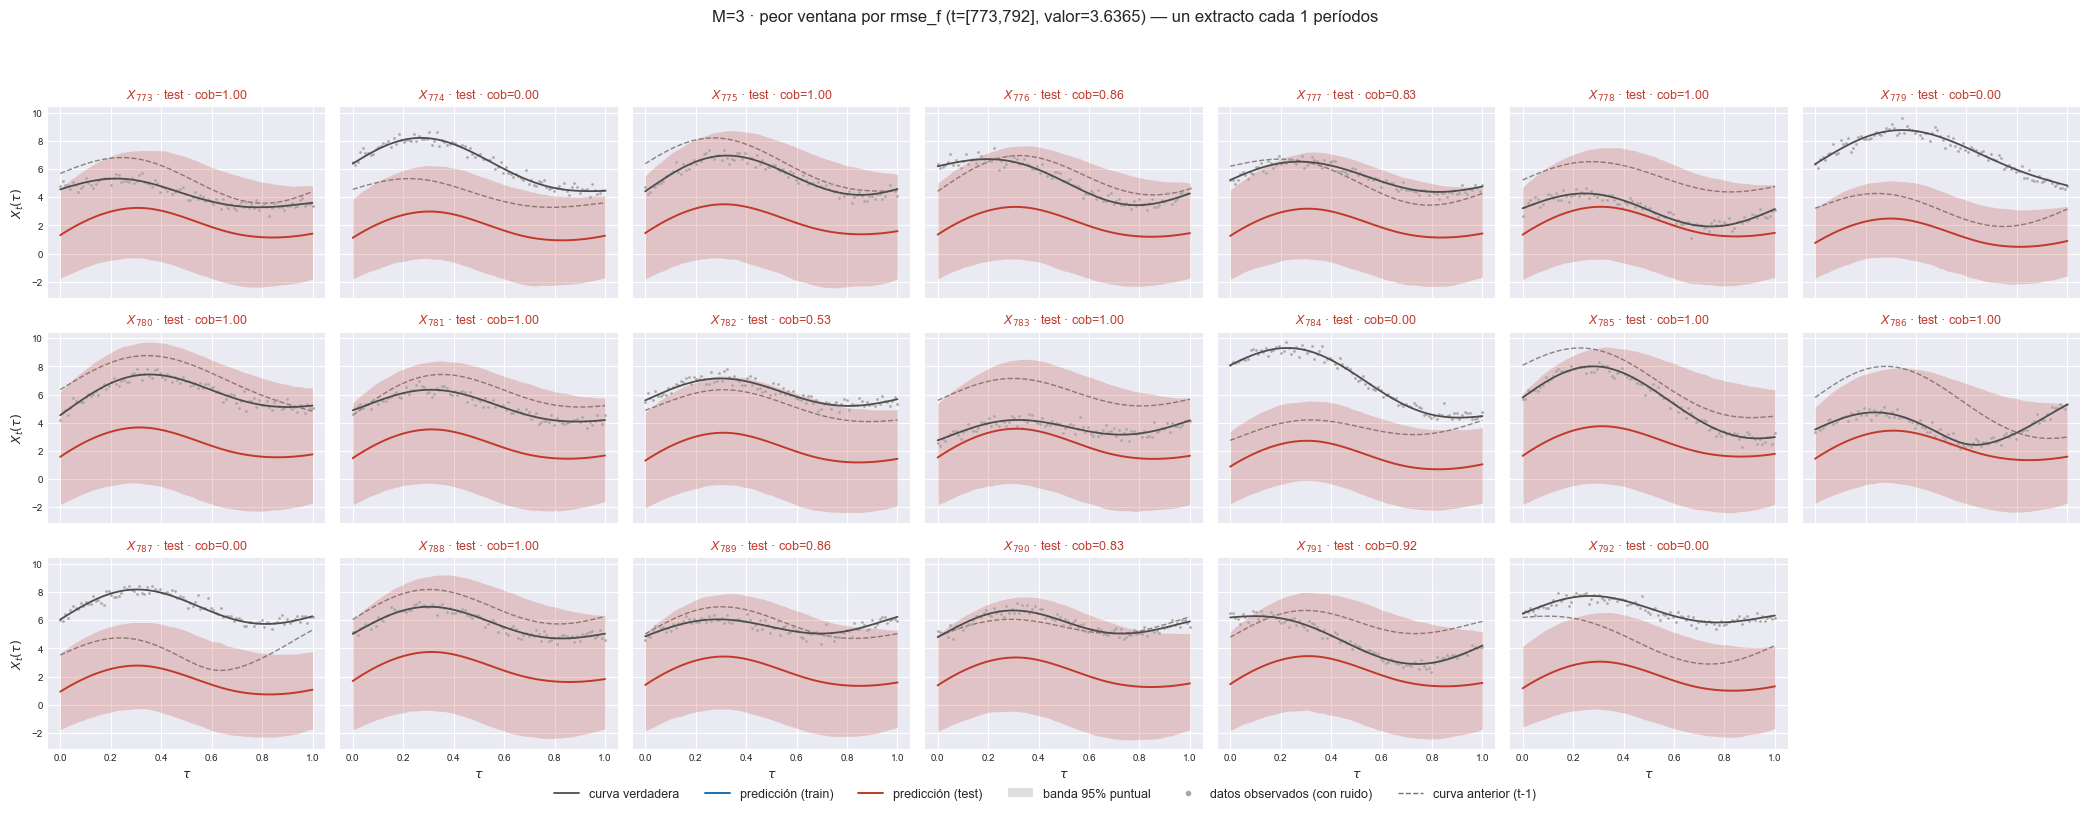

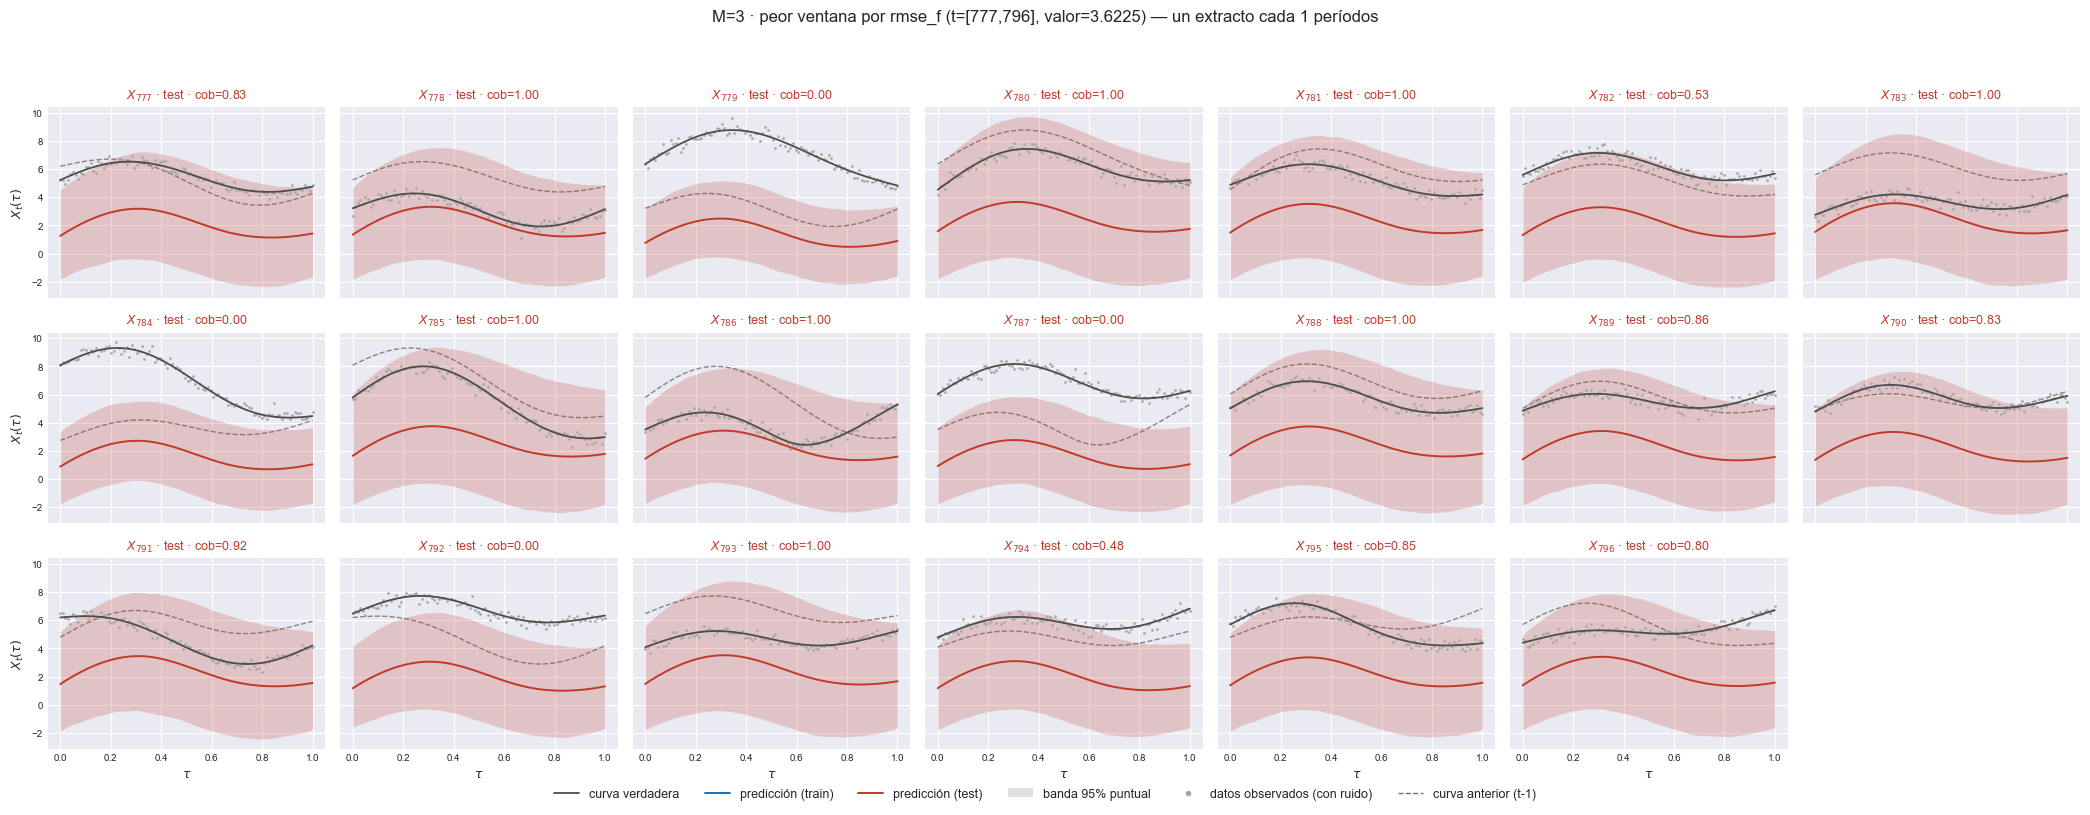

In [19]:
X_prev_full = np.full_like(X_true_ev, np.nan)
X_prev_full[1:] = X_true_ev[:-1]

for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]
    candidatas = tfun[(tfun["bloque"] == "test") & (~tfun["cruza_T0"])]
    if METRICA_PEORES not in candidatas.columns:
        print(f"[M={M}] {METRICA_PEORES!r} no esta en la tabla de ventana; "
              "revisa METRICA_PEORES en [CONFIG].")
        continue
    peores = candidatas.nlargest(N_PEORES, METRICA_PEORES)

    print(f"[M={M}] peores {len(peores)} ventanas por {METRICA_PEORES} "
          f"(w={W_REF}, sólo test, sin cruzar T0):")
    for _, row in peores.iterrows():
        print(f"    t=[{int(row['t_ini'])}, {int(row['t_fin'])}]  "
              f"{METRICA_PEORES}={row[METRICA_PEORES]:.6f}")

    for _, row in peores.iterrows():
        t_ini_exp, t_fin_exp = int(row["t_ini"]), int(row["t_fin"])
        sel = np.where((t_orig >= t_ini_exp) & (t_orig <= t_fin_exp))[0]
        if sel.size == 0:
            continue
        plot_extractos_curvas(
            X_true_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel],
            grilla, T0, t=t_orig[sel], cada=1, n_col=min(len(sel), 7),
            nivel=NIVEL, X_obs=X_obs_ev[sel], X_prev=X_prev_full[sel],
            title=f"M={M} · peor ventana por {METRICA_PEORES} "
                  f"(t=[{t_ini_exp},{t_fin_exp}], valor={row[METRICA_PEORES]:.4f})",
            save_path=str(e["paths"]["out_report"]
                          / f"56b_peor_ventana_{METRICA_PEORES}_t{t_ini_exp}.png"),
            verbose=False)
        plt.show()


## 7. Probabilidades posteriores de inclusión (PIP)

Contra la estructura del generador. Escenario 1: el operador FAR(1) actúa
sobre la curva **completa**, de modo que todas las covariables son
potencialmente activas -no hay aquí un conjunto activo pequeño que contrastar
con especificidad/AUC, como sí lo hay en escenarios con estructura dispersa-.
La cifra útil es `pip_media_activas`.

In [20]:
for M in M_OK:
    e = EST[M]
    pip_df = matriz_pip(e["models_chains"], e["burn"],
                        component_idx=e["component_idx"], verbose=True)
    pip_df.to_csv(e["paths"]["out_report"] / "46_pip.csv")
    e["pip_df"] = pip_df

    cols_pip = [c for c in pip_df.columns if not c.endswith("_sd")]
    display(pip_df.style
        .background_gradient(subset=cols_pip, cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.3f}")
        .set_caption(f"M={M} · P(gamma_j = 1 | datos), inclusión global, "
                     "media entre cadenas ± sd"))

    sd_cols = [c for c in pip_df.columns if c.endswith("_sd")]
    sd_max = float(pip_df[sd_cols].to_numpy().max()) if sd_cols else float("nan")
    e["pip_sd_max"] = sd_max
    print(f"[M={M}] dispersión máxima entre cadenas: {sd_max:.3f}"
          + ("   ! las cadenas discrepan sobre la selección" if sd_max > 0.15
             else "   OK las cadenas coinciden"))


[matriz_pip] inicio (1 pasos)
  1/1 (100.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 1 variables, PIP en [1.000, 1.000]
[matriz_pip] listo: 1 pasos en 0.0s  tabla 1x2


,FPC 1,FPC 1_sd
variable,,
fpc_1_lag1,1.000,0.000


[M=1] dispersión máxima entre cadenas: 0.000   OK las cadenas coinciden
[matriz_pip] inicio (2 pasos)
  1/2 (50.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 2 variables, PIP en [0.024, 1.000]
  2/2 (100.0%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 2 variables, PIP en [0.036, 0.883]
[matriz_pip] listo: 2 pasos en 0.0s  tabla 2x4


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd
variable,,,,
fpc_1_lag1,1.000,0.000,0.036,0.004
fpc_2_lag1,0.024,0.021,0.883,0.029


[M=2] dispersión máxima entre cadenas: 0.029   OK las cadenas coinciden
[matriz_pip] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 3 variables, PIP en [0.017, 1.000]
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 3 variables, PIP en [0.027, 0.876]
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3: 2 cadenas, 3 variables, PIP en [0.023, 0.856]
[matriz_pip] listo: 3 pasos en 0.0s  tabla 3x6


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd,FPC 3,FPC 3_sd
variable,,,,,,
fpc_1_lag1,1.000,0.000,0.036,0.010,0.023,0.005
fpc_2_lag1,0.017,0.007,0.876,0.036,0.023,0.010
fpc_3_lag1,0.024,0.011,0.027,0.001,0.856,0.011


[M=3] dispersión máxima entre cadenas: 0.036   OK las cadenas coinciden


In [21]:
for M in M_OK:
    e = EST[M]
    # [CONFIG] estructura verdadera del generador. Escenario 1: operador
    # lineal sobre toda la curva => todas las covariables son potencialmente
    # activas.
    VERDAD = {f"FPC {e['component_idx'][k] + 1}": list(e["cov_names"])
              for k in range(e["n_components"])}

    contraste = contraste_con_verdad(e["pip_df"], VERDAD, umbral=0.5)
    e["contraste"] = contraste
    if not contraste.empty:
        contraste.to_csv(e["paths"]["out_report"] / "47_contraste_pip.csv")
        display(contraste.style.format("{:.3f}", subset=[
            c for c in contraste.columns if contraste[c].dtype.kind == "f"])
            .set_caption(f"M={M} · selección de variables vs estructura del "
                         "generador (umbral 0.5)"))

print("Con todas las covariables activas, especificidad y AUC no están "
      "definidas de forma informativa: la cifra útil es `pip_media_activas`.")


,n_activas,VP,FP,FN,VN,sensibilidad,especificidad,exactitud,auc,pip_media_activas,pip_media_inactivas
componente,,,,,,,,,,,
FPC 1,1,1,0,0,0,1.000,0.000,1.000,nan,1.000,nan


,n_activas,VP,FP,FN,VN,sensibilidad,especificidad,exactitud,auc,pip_media_activas,pip_media_inactivas
componente,,,,,,,,,,,
FPC 1,2,1,0,1,0,0.500,0.000,0.500,nan,0.512,nan
FPC 2,2,1,0,1,0,0.500,0.000,0.500,nan,0.459,nan


,n_activas,VP,FP,FN,VN,sensibilidad,especificidad,exactitud,auc,pip_media_activas,pip_media_inactivas
componente,,,,,,,,,,,
FPC 1,3,1,0,2,0,0.333,0.000,0.333,nan,0.347,nan
FPC 2,3,1,0,2,0,0.333,0.000,0.333,nan,0.313,nan
FPC 3,3,1,0,2,0,0.333,0.000,0.333,nan,0.301,nan


Con todas las covariables activas, especificidad y AUC no están definidas de forma informativa: la cifra útil es `pip_media_activas`.


## 8. Cuadro resumen: mínimo, máximo y promedio

La ventana móvil genera una SERIE por métrica, no una cifra. Esta tabla es la
lectura resumida de esa serie: mínimo, máximo y promedio, por bloque
train/test, excluyendo las ventanas que cruzan $T_0$ -su cifra mezcla dentro y
fuera de muestra-. Cubre las 7 métricas de los Bloques A y B; ninguna se
destaca sobre las demás.

In [22]:
METRICAS_RESUMEN = METRICAS_A + METRICAS_B   # las 6 con lectura por ventana

resumen_M = []
for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]
    limpio = tfun[~tfun["cruza_T0"]]

    filas = []
    for etiqueta, col in METRICAS_RESUMEN:
        for bloque in ("train", "test"):
            v = limpio.loc[limpio.bloque == bloque, col]
            filas.append({"metrica": etiqueta, "columna": col, "bloque": bloque,
                          "minimo": float(v.min()), "maximo": float(v.max()),
                          "promedio": float(v.mean())})
    resumen = pd.DataFrame(filas).set_index(["metrica", "bloque"])
    resumen.to_csv(e["paths"]["out_report"] / "66_metricas_resumen.csv")
    e["resumen_df"] = resumen

    display(resumen.style
            .format({"minimo": "{:.6f}", "maximo": "{:.6f}", "promedio": "{:.6f}"})
            .set_caption(f"M={M} · mínimo / máximo / promedio por ventana "
                         f"(w={W_REF}, sin cruzar T0) · nivel funcional"))

    picp_pt = float(limpio.loc[limpio.bloque == "test", "picp"].mean())
    picp_si = float(limpio.loc[limpio.bloque == "test", "picp_simultaneo"].mean())
    print(f"[M={M}] PICP puntual test = {picp_pt:.4f} (nominal {NIVEL:.2f})  ·  "
          f"PICP simultáneo test = {picp_si:.4f}")

    # El indicador I_t por origen, en sus dos versiones -de las que (picp) y
    # (picp_simultaneo) son el promedio-. Se persiste porque el promedio
    # esconde DONDE falla la banda.
    I_t_puntual    = indicador_cobertura(X_true_ev, e["li_f"], e["ls_f"]).mean(axis=1)
    I_t_simultaneo = indicador_cobertura_simultanea(X_true_ev, e["li_f"], e["ls_f"])
    ind = pd.DataFrame({
        "t": np.arange(len(I_t_puntual)) + N_LAGS + 1,
        "bloque": np.where(es_train, "train", "test"),
        "I_t_puntual": I_t_puntual,
        "I_t_simultaneo": I_t_simultaneo.astype(float),
    })
    ind.to_csv(e["paths"]["out_report"] / "67_indicador_cobertura.csv",
               index=False)

    m_ = resumen.reset_index()
    m_["M"] = M
    resumen_M.append(m_)

resumen_barrido = pd.concat(resumen_M, ignore_index=True)
resumen_barrido.to_csv(PATH_BARRIDO / "89_resumen_por_M.csv", index=False)
display(resumen_barrido[resumen_barrido.bloque == "test"]
        .pivot(index="metrica", columns="M", values="promedio")
        .style.format("{:.6f}")
        .set_caption("Promedio en TEST contra M (89_resumen_por_M.csv)"))


[M=1] PICP puntual test = 0.7286 (nominal 0.95)  ·  PICP simultáneo test = 0.3500


[M=2] PICP puntual test = 0.7734 (nominal 0.95)  ·  PICP simultáneo test = 0.4853


[M=3] PICP puntual test = 0.7830 (nominal 0.95)  ·  PICP simultáneo test = 0.5183


M,1,2,3
metrica,,,
1. MAE (L^1),2.250490,2.277109,2.266138
2. RMSE (L^2),2.586196,2.610682,2.599771
"3. Error maximo (L^inf, prom. por curva)",3.049225,3.073757,3.061391
4. Winkler,19.468855,17.632595,17.199107
6a. PICP puntual,0.728595,0.773367,0.782950
6b. PICP simultaneo (curva completa),0.350000,0.485294,0.518326
7. MPIW,5.709070,6.178506,6.221926


## 9. Monitoreo univariado por componente FPCA

Cada componente FPCA retenida se predice de manera univariada dentro del
modelo -es una mezcla por componente-, así que aquí se mira su MAE, RMSE y
MISE (= RMSE² del score, el análogo puntual del MISE funcional) por separado,
sobre la ventana móvil. Con $M=1$ hay una sola línea por panel; con $M=k$ hay
$k$ líneas, una por componente. **Solo monitoreo**: ninguna de las tres es
primaria.

In [23]:
# `verbose` sólo en el ancho de referencia: con todos los anchos y todos los M
# la salida serían miles de líneas.
for M in M_OK:
    e = EST[M]
    etiquetas = [f"FPC {i + 1}" for i in e["component_idx"]]
    tablas_score = {
        w: ventana_movil_scores(
            e["Y_obs"], e["Y_hat"], T0_orig, w=w, muestras=e["SC_draws"],
            li=e["li_s"], ls=e["ls_s"], t_offset=N_LAGS,
            etiquetas=etiquetas, verbose=(w == W_REF))
        for w in VENTANAS_W
    }
    e["tablas_score"] = tablas_score
    tablas_score[W_REF].to_csv(
        e["paths"]["out_report"] / f"90_ventana_scores_w{W_REF}.csv", index=False)


[ventana_movil_scores[FPC 1, w=20]] inicio (780 pasos)
  1/780 ( 0.1%) t=0.0s eta=1.1s  t=11 [train] rmse=0.7739
  39/780 ( 5.0%) t=0.0s eta=0.1s  t=49 [train] rmse=0.9086
  78/780 (10.0%) t=0.0s eta=0.1s  t=88 [train] rmse=0.9151
  117/780 (15.0%) t=0.0s eta=0.1s  t=127 [train] rmse=0.9662
  156/780 (20.0%) t=0.0s eta=0.1s  t=166 [train] rmse=0.8346
  195/780 (25.0%) t=0.0s eta=0.1s  t=205 [train] rmse=1.039
  234/780 (30.0%) t=0.0s eta=0.1s  t=244 [train] rmse=0.6907
  273/780 (35.0%) t=0.1s eta=0.1s  t=283 [train] rmse=0.8835
  312/780 (40.0%) t=0.1s eta=0.1s  t=322 [train] rmse=0.7532
  351/780 (45.0%) t=0.1s eta=0.1s  t=361 [train] rmse=0.7624
  390/780 (50.0%) t=0.1s eta=0.1s  t=400 [train] rmse=1.043
  429/780 (55.0%) t=0.1s eta=0.1s  t=439 [train] rmse=1.173
  468/780 (60.0%) t=0.1s eta=0.1s  t=478 [train] rmse=0.8723
  507/780 (65.0%) t=0.1s eta=0.0s  t=517 [train] rmse=1.095
  546/780 (70.0%) t=0.1s eta=0.0s  t=556 [train] rmse=1.141
  585/780 (75.0%) t=0.1s eta=0.0s  t=595 [

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  mae: w=20 train=0.739  w=20 test=1.506
  2/3 (66.7%) t=0.0s eta=0.0s  rmse: w=20 train=0.922  w=20 test=1.77
  3/3 (100.0%) t=0.1s eta=0.0s  mise: w=20 train=0.8501  w=20 test=3.134
[plot_ventana_movil] listo: 3 pasos en 0.6s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m01\91_ventana_univariado.png


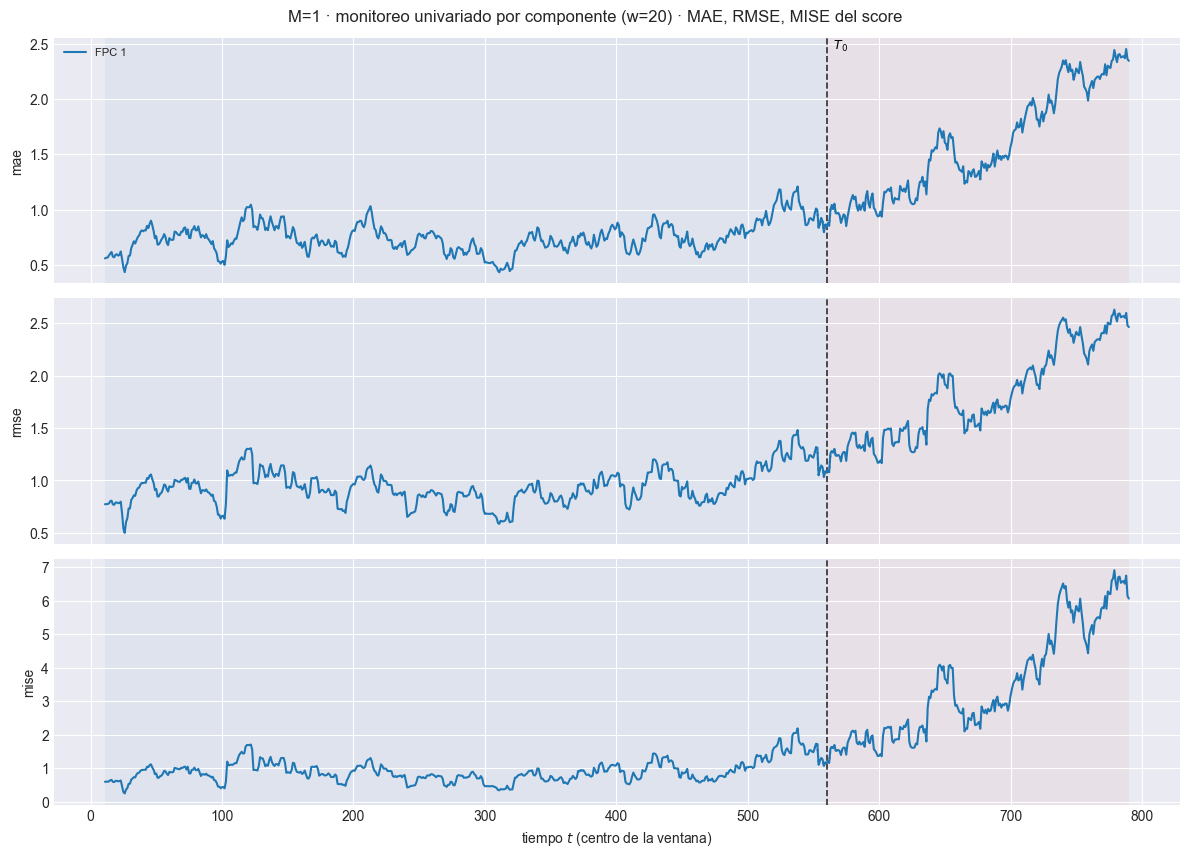

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.1s  mae: w=20 train=0.7706  w=20 test=0.9972
  2/3 (66.7%) t=0.0s eta=0.0s  rmse: w=20 train=0.9605  w=20 test=1.25
  3/3 (100.0%) t=0.1s eta=0.0s  mise: w=20 train=0.9225  w=20 test=1.562
[plot_ventana_movil] listo: 3 pasos en 0.7s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m02\91_ventana_univariado.png


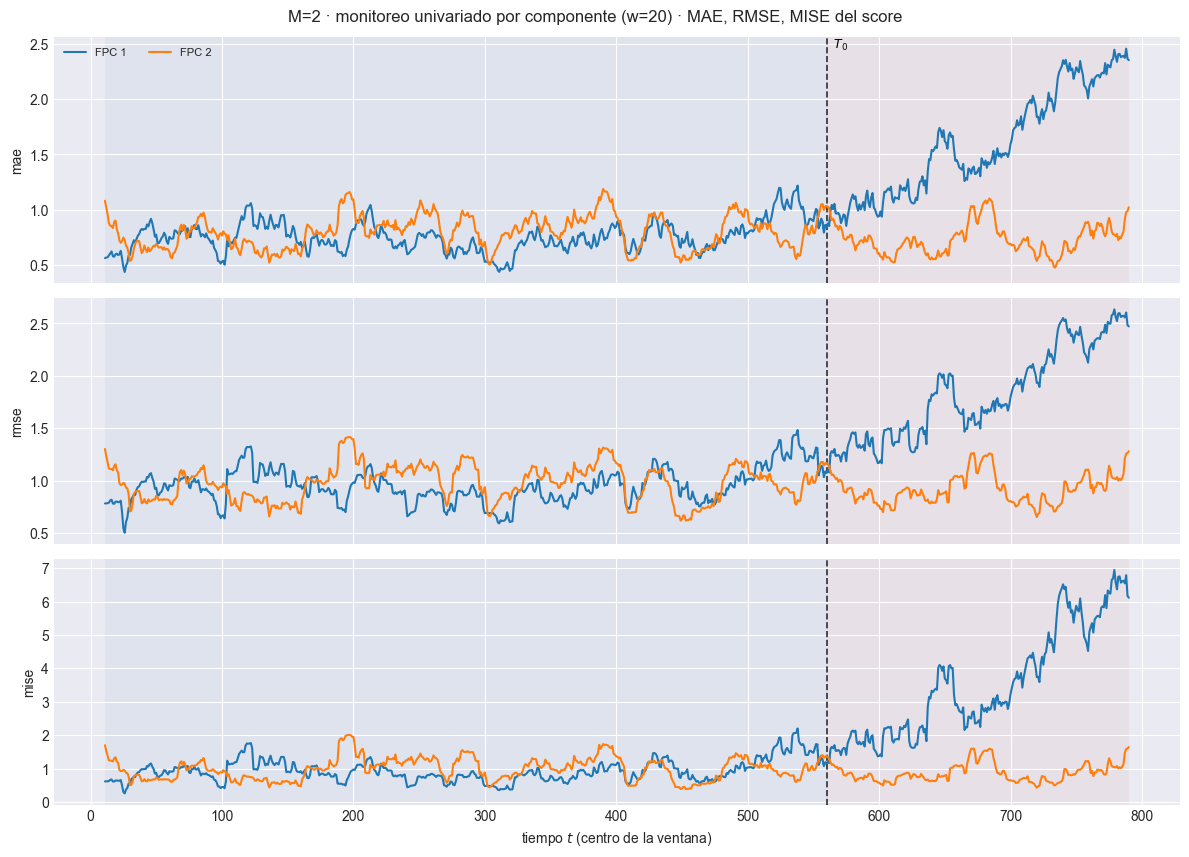

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  mae: w=20 train=0.7777  w=20 test=1.187
  2/3 (66.7%) t=0.1s eta=0.0s  rmse: w=20 train=0.9666  w=20 test=1.42
  3/3 (100.0%) t=0.1s eta=0.0s  mise: w=20 train=0.9342  w=20 test=2.017
[plot_ventana_movil] listo: 3 pasos en 0.7s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m03\91_ventana_univariado.png


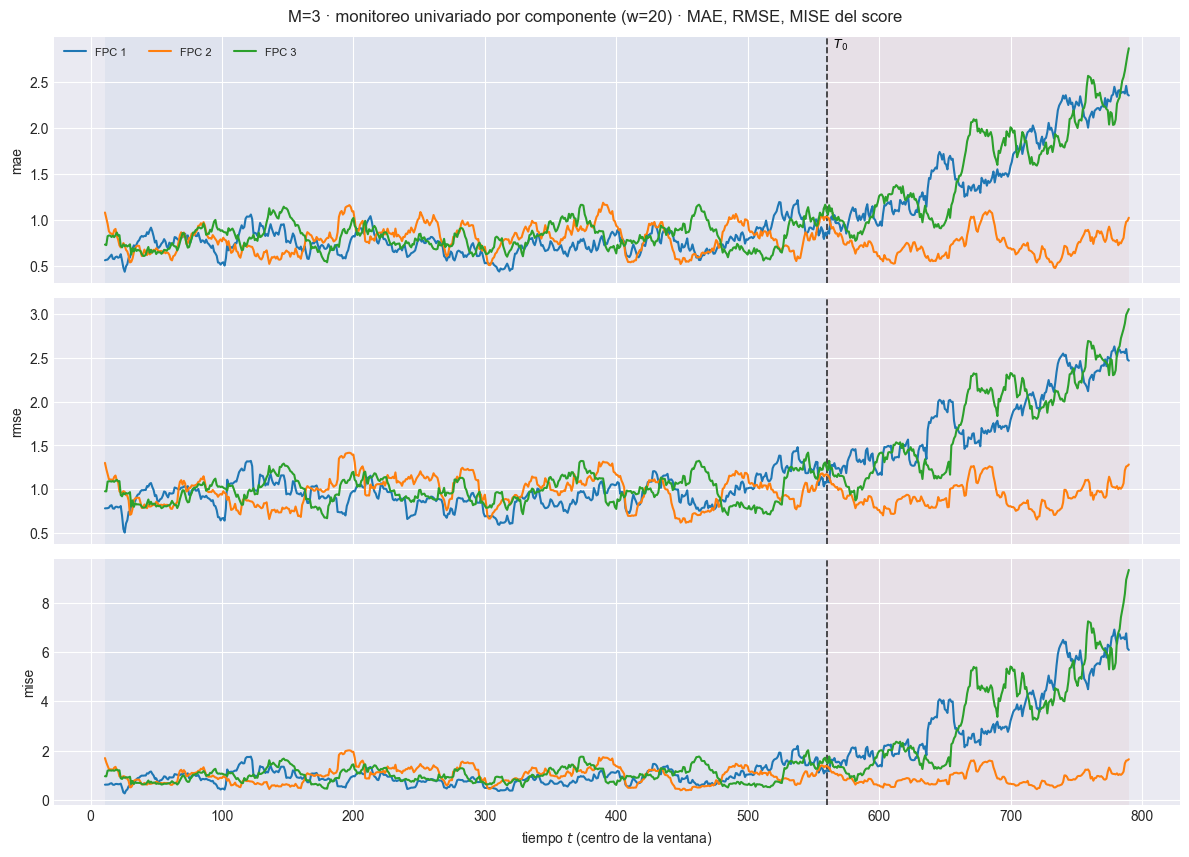

In [24]:
for M in M_OK:
    e = EST[M]
    tsc = e["tablas_score"][W_REF].copy()
    tsc["mise"] = tsc["rmse"] ** 2       # MSE del score: analogo puntual del MISE

    plot_ventana_movil(
        tsc, T0, ["mae", "rmse", "mise"], columna_grupo="componente",
        title=f"M={M} · monitoreo univariado por componente (w={W_REF}) · "
              "MAE, RMSE, MISE del score",
        save_path=str(e["paths"]["out_report"] / "91_ventana_univariado.png"),
        verbose=True)
    plt.show()
